## Procesado de datos financieros de alta frecuencia para ML

Tarea realizada por **MATEO SANTOS GARCÍA** y **OSCAR ROMERO QUINCOCES**

Este notebook implementa un pipeline de preprocesado de datos financieros de alta frecuencia para BTC/USDT (datos de 1 minuto) siguiendo un enfoque inspirado en Marcos López de Prado. El objetivo es transformar datos brutos en una estructura adecuada para modelos de machine learning, respetando la naturaleza temporal y el ruido propio de los mercados financieros.

**Resumen de las etapas del pipeline:**
- **Sección 0**: Setup, parámetros globales y carga inicial de datos.
- **Sección 1**: Construcción y comparación de barras alternativas (tick, volumen, dólar) y selección de dollar bars.
- **Sección 2**: Diferenciación fraccional de la serie de precios y elección del grado de diferenciación.
- **Sección 3**: Construcción de features internas y limpieza de la matriz de covarianza mediante eigenvalue clipping.
- **Sección 4**: Etiquetado de eventos con el método de triple barrera (thresholds fijos y dinámicos).
- **Sección 5**: Definición de esquemas de validación cruzada temporal (70/30, 80/20, 90/10).


## 0. Setup global del entorno

En esta sección se importan las librerías básicas y se fijan los parámetros globales del análisis. 


In [1]:
# =========================
# Librerías y configuración
# =========================

import kagglehub
import glob
from pathlib import Path
import os
import shutil
import random

import numpy as np
import pandas as pd

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

from sklearn.neighbors import KernelDensity
from sklearn.model_selection import TimeSeriesSplit, KFold
from sklearn.preprocessing import StandardScaler  # si luego se usa en otras fases

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

# Estilo de gráficos
plt.style.use("default")

# =========================
# Parámetros (rango temporal)
# =========================

DATE_START = "2023-02-28"
DATE_END   = "2026-02-28"

print("Rango temporal configurado:")
print(f"  Fecha inicio: {DATE_START}")
print(f"  Fecha fin   : {DATE_END}")

Rango temporal configurado:
  Fecha inicio: 2023-02-28
  Fecha fin   : 2026-02-28


### 0.1. Descarga y localización del archivo de datos

En esta sección se descarga el dataset histórico de BTC/USDT desde Kaggle mediante `kagglehub` y se localiza de forma automática el archivo CSV correcto dentro de la carpeta descargada. 

In [2]:
# Descarga del dataset de Kaggle y localización del archivo CSV principal

# Código de descarga fijado por el enunciado (no modificar)
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
print("Path to dataset files:", path)

# Búsqueda recursiva de todos los archivos CSV dentro del path descargado
csv_pattern = os.path.join(path, "**", "*.csv")
csv_files = glob.glob(csv_pattern, recursive=True)

if not csv_files:
    raise FileNotFoundError("No se encontraron archivos CSV en la ruta descargada de Kaggle.")

print("\nArchivos CSV encontrados:")
for f in csv_files:
    print("  -", f)

# Estrategia de selección del archivo principal:
# 1) Preferir archivos cuyo nombre contenga referencias a BTCUSD/BTCUSDT.
# 2) Si no se encuentra ninguno, seleccionar el CSV de mayor tamaño (en bytes).

preferred_keywords = ["btcusd", "btcusdt", "btc_usd", "btc-usd"]

candidates_preferred = []
for f in csv_files:
    name_lower = os.path.basename(f).lower()
    if any(kw in name_lower for kw in preferred_keywords):
        candidates_preferred.append(f)

if candidates_preferred:
    # Si hay varios candidatos preferidos, elegir el más grande por tamaño
    csv_path = max(candidates_preferred, key=lambda p: os.path.getsize(p))
    strategy = "archivo con nombre que coincide con BTCUSD/BTCUSDT"
else:
    # Si no hay coincidencias en el nombre, elegir el CSV más grande en general
    csv_path = max(csv_files, key=lambda p: os.path.getsize(p))
    strategy = "archivo CSV de mayor tamaño (fallback)"

print("\nArchivo CSV seleccionado (", strategy, "):", sep="")
print("  ", csv_path)

# Guardamos la ruta seleccionada en una variable global para reutilizarla después
DATA_CSV_PATH = csv_path

100%|██████████| 101M/101M [00:57<00:00, 1.85MB/s] 

Extracting files...


Path to dataset files: C:\Users\mateo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\542

Archivos CSV encontrados:
  - C:\Users\mateo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\542\btcusd_1-min_data.csv

Archivo CSV seleccionado (archivo con nombre que coincide con BTCUSD/BTCUSDT):
   C:\Users\mateo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\542\btcusd_1-min_data.csv


### 0.2. Carga del CSV e inspección inicial del dataset

En esta sección se carga el archivo CSV seleccionado en un `DataFrame` de `pandas` y se realiza una inspección inicial básica (forma, tipos de datos, primeras y últimas filas). También se detecta de forma robusta cuál es la columna temporal y se comprueba si los datos están ordenados de forma cronológica o inversa.



In [3]:
# Carga del CSV seleccionado y exploración básica

# Leemos el archivo CSV seleccionado en la celda anterior
print("Leyendo CSV desde:")
print("  ", DATA_CSV_PATH)

df_raw = pd.read_csv(DATA_CSV_PATH)

print("\nDimensiones del DataFrame bruto:")
print("  shape =", df_raw.shape)

print("\nTipos de datos (dtypes):")
print(df_raw.dtypes)

print("\nPrimeras 3 filas:")
display(df_raw.head(3))

print("\nÚltimas 3 filas:")
display(df_raw.tail(3))

print("\nResumen df.info():")
df_raw.info()

# ----------------------------------------------------------------------
# Detección robusta de la columna temporal
# ----------------------------------------------------------------------

possible_time_names = [
    "timestamp", "date", "time", "datetime", "open time", "open_time"
]

# Buscamos coincidencias case-insensitive y permitimos espacios/guiones bajos
lower_cols = {col.lower(): col for col in df_raw.columns}

found_time_col = None
for candidate in possible_time_names:
    for col_lower, col_original in lower_cols.items():
        if candidate in col_lower:
            found_time_col = col_original
            break
    if found_time_col is not None:
        break

if found_time_col is None:
    raise ValueError(
        "No se pudo detectar una columna temporal. Revise los nombres de columna "
        "y actualice la lista de posibles variantes."
    )

print("\nColumna temporal detectada:")
print("  ", found_time_col)

# ----------------------------------------------------------------------
# Detección de si el orden temporal está invertido
# ----------------------------------------------------------------------

# Tomamos algunas muestras del principio y del final para intentar inferir el orden
sample_start = df_raw[found_time_col].head(5)
sample_end = df_raw[found_time_col].tail(5)

# Intentamos convertir estas muestras a datetime de forma flexible
sample_start_dt = pd.to_datetime(sample_start, errors="coerce")
sample_end_dt = pd.to_datetime(sample_end, errors="coerce")

is_reverse_order = False
if not sample_start_dt.isna().all() and not sample_end_dt.isna().all():
    first_ts = sample_start_dt.iloc[0]
    last_ts = sample_end_dt.iloc[-1]
    if pd.notna(first_ts) and pd.notna(last_ts):
        is_reverse_order = first_ts > last_ts

if is_reverse_order:
    print("\nOrden temporal detectado: INVERSO (últimas fechas primero). Se corregirá en la etapa de limpieza temporal.")
else:
    print("\nOrden temporal detectado: CRONOLÓGICO o no claramente inverso (se confirmará tras la conversión a datetime).")

# Guardamos el nombre de la columna temporal para usarlo en la siguiente fase
time_column_name = found_time_col

Leyendo CSV desde:
   C:\Users\mateo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\542\btcusd_1-min_data.csv

Dimensiones del DataFrame bruto:
  shape = (7473282, 6)

Tipos de datos (dtypes):
Timestamp    float64
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object

Primeras 3 filas:


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0



Últimas 3 filas:


,Timestamp,Open,High,Low,Close,Volume
7473279,1.773878e+09,71241.0,71241.0,71215.0,71220.0,0.479915
7473280,1.773878e+09,71194.0,71232.0,71194.0,71219.0,1.203673
7473281,1.773879e+09,71219.0,71232.0,71200.0,71200.0,1.879731



Resumen df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7473282 entries, 0 to 7473281
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 342.1 MB

Columna temporal detectada:
   Timestamp

Orden temporal detectado: CRONOLÓGICO o no claramente inverso (se confirmará tras la conversión a datetime).


### 0.3. Limpieza temporal y estandarización de columnas OHLCV

En esta sección se normaliza la dimensión temporal del dataset: se convierte la columna temporal detectada a tipo `datetime`, se renombra a un nombre estándar (`datetime`), se establece como índice y se ordena cronológicamente. Además, se estandarizan los nombres de las columnas OHLCV a formato `open`, `high`, `low`, `close`, `volume`.



In [4]:
# Limpieza temporal y estandarización de columnas OHLCV

if 'df_raw' not in globals():
    raise RuntimeError("df_raw no está definido. Ejecute primero las celdas de descarga y carga del CSV.")

# Copiamos el DataFrame bruto para trabajar sobre una versión intermedia
df = df_raw.copy()

# ----------------------------------------------------------------------
# Conversión de la columna temporal a datetime y renombrado estándar
# ----------------------------------------------------------------------

time_series = df[time_column_name]

# Detectamos si la columna temporal es numérica (posible Unix timestamp)
if pd.api.types.is_numeric_dtype(time_series):
    # Asumimos Unix timestamp en segundos, según la especificación del enunciado
    df['datetime'] = pd.to_datetime(time_series, unit='s', errors='coerce')
else:
    # Asumimos strings o tipos ya convertibles a datetime
    df['datetime'] = pd.to_datetime(time_series, errors='coerce', infer_datetime_format=True)

# Comprobamos si hay conversiones fallidas
n_invalid_dt = df['datetime'].isna().sum()
if n_invalid_dt > 0:
    print(f"Advertencia: {n_invalid_dt} filas tienen fecha/hora no convertible y se eliminarán.")
    df = df.dropna(subset=['datetime'])

# Establecemos 'datetime' como índice
df = df.drop(columns=[time_column_name])  # Eliminamos la columna original

# Orden cronológico ascendente
df = df.set_index('datetime').sort_index()

print("Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.")

# ----------------------------------------------------------------------
# Estandarización de nombres de columnas OHLCV
# ----------------------------------------------------------------------

# Mapeo genérico de patrones a nombres estándar
ohlcv_targets = {
    'open': ['open'],
    'high': ['high', 'high_price'],
    'low':  ['low', 'low_price'],
    'close': ['close', 'close_price', 'price'],
    'volume': ['volume', 'volume_(btc)', 'volume_(currency)', 'vol']
}

col_mapping = {}
remaining_cols = list(df.columns)

for target_name, patterns in ohlcv_targets.items():
    found_col = None
    for col in remaining_cols:
        col_lower = col.lower()
        for pattern in patterns:
            if pattern in col_lower:
                found_col = col
                break
        if found_col is not None:
            break
    if found_col is not None:
        col_mapping[found_col] = target_name
        remaining_cols.remove(found_col)

# Renombramos las columnas encontradas
if col_mapping:
    df = df.rename(columns=col_mapping)

print("\nMapa de renombrado aplicado a columnas OHLCV:")
for orig, new in col_mapping.items():
    print(f"  {orig} -> {new}")

# ----------------------------------------------------------------------
# Eliminación de columnas no OHLCV
# ----------------------------------------------------------------------

cols_ohlcv = ['open', 'high', 'low', 'close', 'volume']

cols_present = [c for c in cols_ohlcv if c in df.columns]
if len(cols_present) < len(cols_ohlcv):
    missing = [c for c in cols_ohlcv if c not in df.columns]
    print("\nAdvertencia: faltan algunas columnas OHLCV esperadas:", missing)

# Seleccionamos solo las columnas OHLCV disponibles
cols_to_keep = cols_present

# Comentario: nos quedamos únicamente con OHLCV porque el objetivo de esta fase
# es trabajar con precios y volúmenes básicos; columnas auxiliares como
# 'Volume_(Currency)' o 'Weighted_Price' se descartan para simplificar el
# preprocesado y evitar duplicar información altamente correlacionada.

df = df[cols_to_keep]

print("\nColumnas finales tras la estandarización OHLCV:")
print(list(df.columns))

# Mostramos un pequeño resumen para verificar el resultado
print("\nResumen tras la limpieza temporal y estandarización OHLCV:")
print("  shape =", df.shape)
print("  Índice (datetime) desde", df.index.min(), "hasta", df.index.max())

Índice temporal estandarizado a 'datetime' y ordenado cronológicamente.

Mapa de renombrado aplicado a columnas OHLCV:
  Open -> open
  High -> high
  Low -> low
  Close -> close
  Volume -> volume

Columnas finales tras la estandarización OHLCV:
['open', 'high', 'low', 'close', 'volume']

Resumen tras la limpieza temporal y estandarización OHLCV:
  shape = (7473282, 5)
  Índice (datetime) desde 2012-01-01 10:01:00 hasta 2026-03-19 00:02:00


### 0.4. Filtrado temporal parametrizable con DATE_START y DATE_END

En esta sección se aplica el filtrado temporal sobre el índice `datetime` utilizando los parámetros globales `DATE_START` y `DATE_END`. El objetivo es trabajar únicamente con una ventana de datos coherente y controlada (por ejemplo, 3 años de datos de 1 minuto).


In [5]:
# Filtrado temporal usando DATE_START y DATE_END

if 'df' not in globals():
    raise RuntimeError("df no está definido. Ejecute antes la celda de limpieza temporal (sección 3).")

# Convertimos las fechas de los parámetros globales a datetime
start_dt = pd.to_datetime(DATE_START)
end_dt = pd.to_datetime(DATE_END)

# Aplicamos el filtrado sobre el índice datetime
mask = (df.index >= start_dt) & (df.index <= end_dt)
df_window = df.loc[mask].copy()

if df_window.empty:
    raise ValueError(
        f"El filtrado temporal con DATE_START={DATE_START} y DATE_END={DATE_END} "
        "ha producido un DataFrame vacío. Revise el rango de fechas."
    )

n_rows = len(df_window)
print("Número de registros tras el filtrado temporal:", n_rows)
print("Rango real de fechas en la ventana filtrada:")
print("  Fecha mínima:", df_window.index.min())
print("  Fecha máxima:", df_window.index.max())

Número de registros tras el filtrado temporal: 1577081
Rango real de fechas en la ventana filtrada:
  Fecha mínima: 2023-02-28 00:00:00
  Fecha máxima: 2026-02-28 00:00:00


### 0.5. Revisión de calidad del DataFrame filtrado

En esta sección se revisa la calidad del `DataFrame` ya filtrado temporalmente: se contabilizan valores ausentes, se aplican imputaciones controladas (forward fill limitado) sobre las columnas OHLCV cuando sea necesario y se detectan posibles duplicados en el índice temporal.

El objetivo es dejar constancia de los problemas de calidad encontrados y de las decisiones de limpieza tomadas.

In [6]:
# Revisión de calidad: NaNs, imputación controlada y duplicados

if 'df_window' not in globals():
    raise RuntimeError("df_window no está definido. Ejecute antes la celda de filtrado temporal (sección 4).")

# Trabajamos sobre una copia para la limpieza de calidad
df_clean = df_window.copy()

print("Valores ausentes por columna (antes de la imputación):")
na_before = df_clean.isna().sum()
print(na_before)

# Imputación forward fill limitada en columnas OHLCV si existen NaNs
cols_ohlcv = [c for c in ['open', 'high', 'low', 'close', 'volume'] if c in df_clean.columns]

if cols_ohlcv:
    # Contamos NaNs antes de imputar solo en OHLCV
    na_before_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()

    if na_before_ohlcv > 0:
        print(f"\nAplicando forward fill (ffill) con límite de 5 periodos en columnas OHLCV (NaNs iniciales: {na_before_ohlcv}).")
        df_clean[cols_ohlcv] = df_clean[cols_ohlcv].ffill(limit=5)

        na_after_ohlcv = df_clean[cols_ohlcv].isna().sum().sum()
        imputed = na_before_ohlcv - na_after_ohlcv
        print(f"NaNs imputados en OHLCV: {imputed}")
        print(f"NaNs restantes en OHLCV tras imputación: {na_after_ohlcv}")
    else:
        print("\nNo se detectaron NaNs en columnas OHLCV. No se aplica imputación.")
else:
    print("\nAdvertencia: no se encontraron columnas OHLCV estándar para imputar (open, high, low, close, volume).")

# Recuento de NaNs final (todas las columnas)
print("\nValores ausentes por columna (después de la imputación):")
na_after = df_clean.isna().sum()
print(na_after)

# Detección de duplicados en el índice temporal
n_duplicated = df_clean.index.duplicated().sum()

if n_duplicated > 0:
    print(f"\nAdvertencia: se detectaron {n_duplicated} índices datetime duplicados.")
    # Podríamos decidir cómo resolverlos; por ahora solo se informa.
else:
    print("\nNo se detectaron índices datetime duplicados.")

print("\nResumen final de calidad tras esta sección:")
print("  shape =", df_clean.shape)
print("  Rango de fechas =", df_clean.index.min(), "→", df_clean.index.max())
print("  NaNs totales restantes =", int(df_clean.isna().sum().sum()))

Valores ausentes por columna (antes de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron NaNs en columnas OHLCV. No se aplica imputación.

Valores ausentes por columna (después de la imputación):
open      0
high      0
low       0
close     0
volume    0
dtype: int64

No se detectaron índices datetime duplicados.

Resumen final de calidad tras esta sección:
  shape = (1577081, 5)
  Rango de fechas = 2023-02-28 00:00:00 → 2026-02-28 00:00:00
  NaNs totales restantes = 0


### 0.6. DataFrame final listo para la siguiente fase
En esta sección se muestra un resumen final del `DataFrame` limpio y filtrado que se utilizará como punto de partida para la construcción de barras alternativas en fases posteriores. Se imprimen las primeras filas y la estructura de tipos para verificar que la información relevante (OHLCV e índice temporal) está en el formato esperado.

Cerrar esta fase con una confirmación explícita del estado del `DataFrame` ayuda a documentar que los datos están listos para ser transformados sin necesidad de rehacer el preprocesado previo.

In [7]:
# Resumen final del DataFrame limpio y filtrado

if 'df_clean' not in globals():
    raise RuntimeError("df_clean no está definido. Asegúrese de haber ejecutado las celdas anteriores.")

print("DataFrame final (df_clean): primeras 5 filas:")
display(df_clean.head())

print("\nEstructura de df_clean (info):")
df_clean.info()

print("\nConfirmación:")
print("El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.")

DataFrame final (df_clean): primeras 5 filas:


,open,high,low,close,volume
datetime,,,,,
2023-02-28 00:00:00,23287.0,23287.0,23274.0,23274.0,0.035808
2023-02-28 00:01:00,23284.0,23289.0,23279.0,23289.0,0.108341
2023-02-28 00:02:00,23299.0,23308.0,23295.0,23307.0,1.495817
2023-02-28 00:03:00,23299.0,23308.0,23288.0,23307.0,1.301732
2023-02-28 00:04:00,23299.0,23309.0,23299.0,23300.0,0.565719



Estructura de df_clean (info):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1577081 entries, 2023-02-28 00:00:00 to 2026-02-28 00:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   open    1577081 non-null  float64
 1   high    1577081 non-null  float64
 2   low     1577081 non-null  float64
 3   close   1577081 non-null  float64
 4   volume  1577081 non-null  float64
dtypes: float64(5)
memory usage: 72.2 MB

Confirmación:
El DataFrame df_clean está limpio, filtrado en el rango temporal especificado y listo para la construcción de barras alternativas en la siguiente fase del pipeline.


## 1. Construcción y comparación de barras alternativas

**Propósito**: Transformar la serie de 1 minuto en representaciones alternativas (tick bars, volume bars y dollar bars) y justificar la elección de dollar bars como base para el resto del pipeline.

En series financieras de alta frecuencia, las barras equiespaciadas en tiempo pueden no representar adecuadamente la actividad real del mercado, ya que periodos con distinta intensidad de negociación reciben el mismo peso temporal. Para reducir este efecto, se construyen barras alternativas que agrupan observaciones según criterios de actividad.

| Tipo de barra | Criterio de construcción | Motivación principal | Limitación en este caso |
|---------------|--------------------------|----------------------|--------------------------|
| **Tick Bars** | Agrupan un número fijo de observaciones | Homogeneizar número de eventos por barra | Se aproxima usando datos de 1 minuto, no ticks reales |
| **Volume Bars** | Agrupan hasta acumular un volumen fijo | Igualar actividad negociada | Dependencia del umbral elegido |
| **Dollar Bars** | Agrupan hasta acumular precio × volumen fijo | Capturar flujo de capital negociado | Sensibles a cambios bruscos de precio |

A partir del dataframe de BTC/USDT de 1 minuto se generan tres nuevas series OHLCV aplicando umbrales parametrizables para cada método. Cada barra reconstruye:

- **Open:** primer precio del grupo  
- **High:** máximo precio  
- **Low:** mínimo precio  
- **Close:** último precio  
- **Volume:** volumen total acumulado  

Posteriormente se comparan:

- número total de barras generadas  
- series temporales de precios de cierre  
- distribución de retornos por tipo de barra  

Finalmente se seleccionará **Dollar Bars** como representación base para continuar el pipeline, al aproximar mejor la actividad económica del mercado.

Técnica (López de Prado): barras alternativas (tick, volume y especialmente dollar bars) para estructurar la serie por “información/actividad” y no por tiempo.
AFML (2018) — Cap. 2 (Financial Data Structures / bars).

### 1.0. Parametros barras alternativas

In [8]:
# Parámetros específicos para la Fase 2: construcción de barras alternativas

# Estos valores sirven como punto de partida razonable para 3 años de datos
# de 1 minuto en BTC/USDT. Si el periodo tiene muy poca actividad (pocas
# barras resultantes), puede ser necesario reducir los umbrales; si hay
# demasiadas barras, puede aumentarse su valor.

TICK_SIZE        = 10       # número de ticks (minutos) por barra de tipo tick
VOLUME_THRESHOLD = 10.0      # BTC acumulados por barra de tipo volumen
DOLLAR_THRESHOLD = 750_000.0 # USD acumulados por barra de tipo dólar

print("Parámetros Fase 1:")
print(f"  TICK_SIZE        = {TICK_SIZE}")
print(f"  VOLUME_THRESHOLD = {VOLUME_THRESHOLD}")
print(f"  DOLLAR_THRESHOLD = {DOLLAR_THRESHOLD}")

Parámetros Fase 1:
  TICK_SIZE        = 10
  VOLUME_THRESHOLD = 10.0
  DOLLAR_THRESHOLD = 750000.0


### 1.1. Tick Bars
Las **tick bars** agrupan un número fijo de observaciones consecutivas del DataFrame original (definido por `tick_size`).  


In [9]:
def tick_bars(df, tick_size):
    """Construye tick bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa `tick_size` observaciones consecutivas del DataFrame
    original. La barra resultante tiene:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if tick_size <= 0:
        raise ValueError("tick_size debe ser un entero positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    n = len(df)

    # Recorremos el DataFrame en bloques consecutivos de tamaño tick_size
    for start in range(0, n, tick_size):
        end = start + tick_size
        chunk = df.iloc[start:end]

        if chunk.empty:
            continue

        idx_bar = chunk.index[0]  # datetime del primer tick del grupo

        open_price = float(chunk['open'].iloc[0])
        high_price = float(chunk['high'].max())
        low_price = float(chunk['low'].min())
        close_price = float(chunk['close'].iloc[-1])
        volume_sum = float(chunk['volume'].sum())

        rows.append({
            'datetime': idx_bar,
            'open': open_price,
            'high': high_price,
            'low': low_price,
            'close': close_price,
            'volume': volume_sum,
        })

    df_tick = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_tick)
    print(f"Tick bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 tick bars. Considere reducir TICK_SIZE.")

    return df_tick

### 1.2. Volume Bars

Las **volume bars** se construyen acumulando operaciones hasta que se alcance un **volumen total específico** (`volume_threshold`).  
Cada barra representa aproximadamente la misma cantidad de actividad de mercado, independientemente del tiempo.  

In [10]:
def volume_bars(df, volume_threshold):
    """Construye volume bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa observaciones consecutivas hasta que el volumen acumulado
    supera `volume_threshold`. La barra resultante tiene OHLCV definido como:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if volume_threshold <= 0:
        raise ValueError("volume_threshold debe ser positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    current_start_idx = None
    accumulated_volume = 0.0

    for idx, row in df.iterrows():
        # Inicializamos el inicio del grupo si es la primera fila del grupo
        if current_start_idx is None:
            current_start_idx = idx

        accumulated_volume += float(row['volume'])

        # Comprobamos si hemos alcanzado o superado el umbral de volumen
        if accumulated_volume >= volume_threshold:
            # Extraemos el grupo desde current_start_idx hasta el índice actual
            chunk = df.loc[current_start_idx:idx]

            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

            # Reiniciamos acumulador y comienzo del siguiente grupo
            accumulated_volume = 0.0
            current_start_idx = None

    # Si queda un grupo parcial al final, podemos decidir si conservarlo
    # En este caso lo conservamos si tiene más de una observación.
    if current_start_idx is not None:
        chunk = df.loc[current_start_idx:df.index[-1]]
        if len(chunk) > 0:
            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

    df_volume = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_volume)
    print(f"Volume bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 volume bars. Considere reducir VOLUME_THRESHOLD.")

    return df_volume

### 1.3. Dollar Bars

Las **dollar bars** agrupan operaciones hasta alcanzar un **valor monetario total** (`dollar_threshold`).  
Se calcula como el **precio × volumen** de cada tick, acumulando hasta que se supera el umbral.

In [11]:
def dollar_bars(df, dollar_threshold):
    """Construye dollar bars a partir de un DataFrame OHLCV con frecuencia fija.

    Cada barra agrupa observaciones consecutivas hasta que el volumen nocional
    acumulado (precio de cierre × volumen) supera `dollar_threshold`. La barra
    resultante tiene OHLCV definido como:
    - open  = primer precio de apertura del grupo
    - high  = máximo de máximos del grupo
    - low   = mínimo de mínimos del grupo
    - close = último precio de cierre del grupo
    - volume = suma de volúmenes del grupo

    El índice de cada barra es el datetime del primer tick del grupo.
    """
    if dollar_threshold <= 0:
        raise ValueError("dollar_threshold debe ser positivo.")

    if df.empty:
        raise ValueError("El DataFrame de entrada está vacío.")

    rows = []
    current_start_idx = None
    accumulated_dollars = 0.0

    for idx, row in df.iterrows():
        if current_start_idx is None:
            current_start_idx = idx

        # Volumen nocional: precio de cierre × volumen
        dollar_volume = float(row['close']) * float(row['volume'])
        accumulated_dollars += dollar_volume

        if accumulated_dollars >= dollar_threshold:
            chunk = df.loc[current_start_idx:idx]

            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

            accumulated_dollars = 0.0
            current_start_idx = None

    # Grupo parcial final (si existe)
    if current_start_idx is not None:
        chunk = df.loc[current_start_idx:df.index[-1]]
        if len(chunk) > 0:
            open_price = float(chunk['open'].iloc[0])
            high_price = float(chunk['high'].max())
            low_price = float(chunk['low'].min())
            close_price = float(chunk['close'].iloc[-1])
            volume_sum = float(chunk['volume'].sum())

            rows.append({
                'datetime': current_start_idx,
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': volume_sum,
            })

    df_dollar = pd.DataFrame(rows).set_index('datetime')

    n_bars = len(df_dollar)
    print(f"Dollar bars generadas: {n_bars} barras")
    if n_bars < 20:
        print("Advertencia: se han generado menos de 20 dollar bars. Considere reducir DOLLAR_THRESHOLD.")

    return df_dollar

### 1.4. Construcción práctica de tick, volume y dollar bars

En esta sección se aplican las tres funciones definidas anteriormente al `DataFrame` base de 1 minuto para generar `df_tick`, `df_volume` y `df_dollar`. Se resume cuántas barras produce cada método y el rango temporal que cubren, lo que ayuda a diagnosticar si los parámetros elegidos (tamaño de tick, umbrales de volumen y dólar) son razonables.

El objetivo es obtener una primera verificación de que las barras alternativas se han construido correctamente antes de pasar a las comparaciones visuales y de distribución de retornos.

In [12]:
# Seleccionamos el DataFrame base. Según el enunciado, partimos de `df`
if 'df' in globals():
    df_base = df
elif 'df_clean' in globals():
    df_base = df_clean
else:
    raise RuntimeError("No se ha encontrado un DataFrame base llamado 'df' o 'df_clean'.")

# Filtramos solo el rango de fechas definido en DATE_START y DATE_END
df_base_filtered = df_base.loc[DATE_START:DATE_END]

print("DataFrame base filtrado para barras alternativas:")
print("  shape =", df_base_filtered.shape)
print("  Rango de fechas =", df_base_filtered.index.min(), "→", df_base_filtered.index.max())

# Construimos las tres familias de barras usando solo el DataFrame filtrado
df_tick = tick_bars(df_base_filtered, TICK_SIZE)
df_volume = volume_bars(df_base_filtered, VOLUME_THRESHOLD)
df_dollar = dollar_bars(df_base_filtered, DOLLAR_THRESHOLD)

# Resumen de cada tipo de barra
print("\nResumen de barras generadas:")
for name, df_b in [("Tick bars", df_tick), ("Volume bars", df_volume), ("Dollar bars", df_dollar)]:
    if not df_b.empty:
        print(f"- {name}: {len(df_b)} barras, rango temporal {df_b.index.min()} → {df_b.index.max()}")
    else:
        print(f"- {name}: 0 barras (revisar parámetros).")

print("\nVista previa de las first dollar bars (df_dollar.head()):")
display(df_dollar.head())

DataFrame base filtrado para barras alternativas:
  shape = (1578520, 5)
  Rango de fechas = 2023-02-28 00:00:00 → 2026-02-28 23:59:00
Tick bars generadas: 157852 barras
Volume bars generadas: 137729 barras
Dollar bars generadas: 128613 barras

Resumen de barras generadas:
- Tick bars: 157852 barras, rango temporal 2023-02-28 00:00:00 → 2026-02-28 23:50:00
- Volume bars: 137729 barras, rango temporal 2023-02-28 00:00:00 → 2026-02-28 23:57:00
- Dollar bars: 128613 barras, rango temporal 2023-02-28 00:00:00 → 2026-02-28 23:48:00

Vista previa de las first dollar bars (df_dollar.head()):


,open,high,low,close,volume
datetime,,,,,
2023-02-28 00:00:00,23287.0,23358.0,23260.0,23303.0,37.460705
2023-02-28 00:15:00,23299.0,23336.0,23126.0,23170.0,77.162149
2023-02-28 01:06:00,23170.0,23282.0,23169.0,23282.0,40.089278
2023-02-28 01:52:00,23282.0,23357.0,23282.0,23357.0,42.058258
2023-02-28 02:12:00,23357.0,23410.0,23325.0,23410.0,35.826644


### 1.5. Comparación visual y distribucional de las barras generadas

En esta sección se generan tres tipos de visualizaciones para comparar los métodos de construcción de barras: (i) el número total de barras por método, (ii) la forma de las series de precios de cierre y (iii) la distribución de los retornos logarítmicos. Estas vistas complementarias permiten evaluar tanto la densidad de información como el comportamiento estadístico de cada aproximación.

En particular, la comparación de las distribuciones de retornos proporciona evidencia empírica sobre qué tipo de barras genera retornos con colas menos extremas y una forma más regular, algo clave a la hora de seleccionar la representación base para modelos de ML financieros. Dicho de otra forma, **hemos conseguido eliminar datos redundantes que proporcionaban ruido**. Se puede apreciar claramente en los histogramas con los datos originales, la existencia de un pico muy grande que no aporta información.

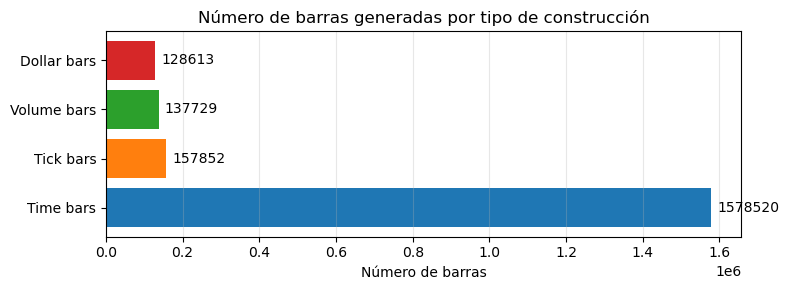

In [21]:
# Gráfica 1: número de barras por método

counts = {
    'Time bars': len(df_base_filtered),
    'Tick bars': len(df_tick),
    'Volume bars': len(df_volume),
    'Dollar bars': len(df_dollar),
}

methods = list(counts.keys())
values = list(counts.values())

y_pos = np.arange(len(methods))

fig, ax = plt.subplots(figsize=(8, 3))

ax.barh(y_pos, values, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Número de barras')
ax.set_title('Número de barras generadas por tipo de construcción')

# Etiquetamos el número exacto a la derecha de cada barra
for i, v in enumerate(values):
    ax.text(v + max(values) * 0.01, i, str(v), va='center')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()


plt.show()

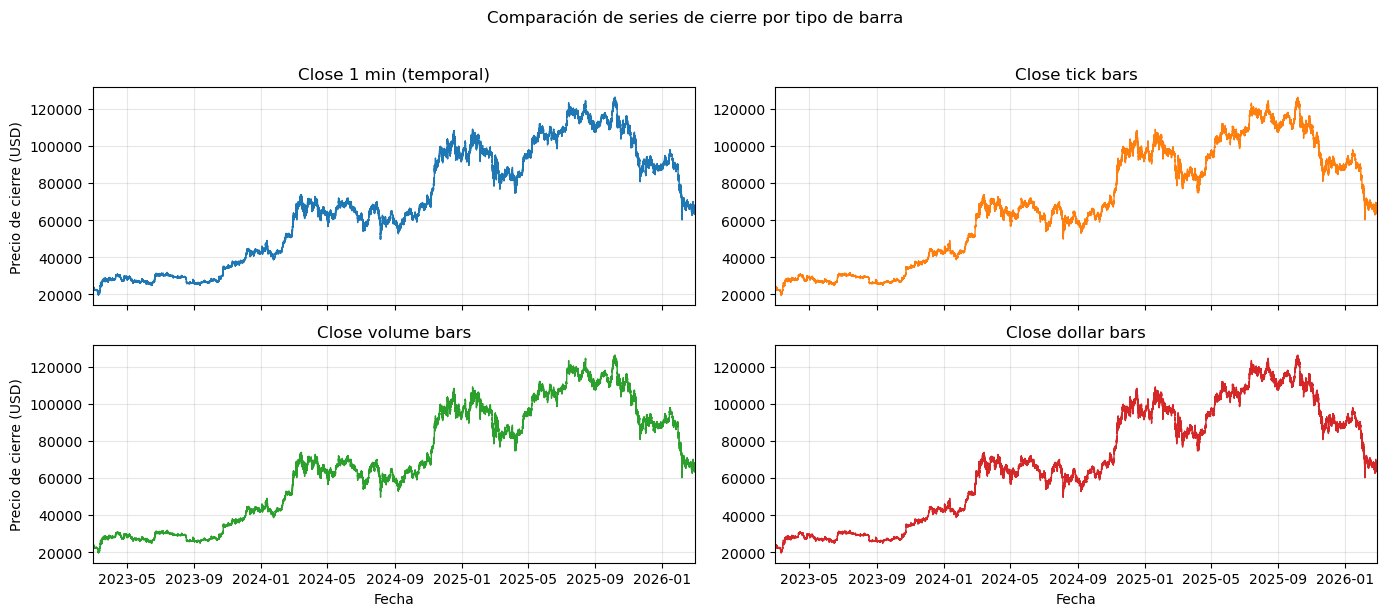

In [22]:
# Gráfica 2: comparación de las series de 'close' por método

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
axes = axes.flatten()

# Determinamos rango temporal común basado en el DataFrame base
if 'df_base' not in globals():
    if 'df' in globals():
        df_base = df
    elif 'df_clean' in globals():
        df_base = df_clean
    else:
        raise RuntimeError("No se ha encontrado un DataFrame base para determinar el rango temporal.")

df_base_filtered = df_base.loc[DATE_START:DATE_END]

x_min = df_base_filtered.index.min()
x_max = df_base_filtered.index.max()

# 0) Serie original de 1 minuto
axes[0].plot(df_base_filtered.index, df_base_filtered['close'], color='tab:blue', linewidth=1)
axes[0].set_title('Close 1 min (temporal)')
axes[0].grid(alpha=0.3)

# 1) Tick bars
axes[1].plot(df_tick.index, df_tick['close'], color='tab:orange', linewidth=1)
axes[1].set_title('Close tick bars')
axes[1].grid(alpha=0.3)

# 2) Volume bars
axes[2].plot(df_volume.index, df_volume['close'], color='tab:green', linewidth=1)
axes[2].set_title('Close volume bars')
axes[2].grid(alpha=0.3)

# 3) Dollar bars
axes[3].plot(df_dollar.index, df_dollar['close'], color='tab:red', linewidth=1)
axes[3].set_title('Close dollar bars')
axes[3].grid(alpha=0.3)

for ax in axes:
    ax.set_xlim(x_min, x_max)

fig.suptitle('Comparación de series de cierre por tipo de barra', y=1.02)

for ax in axes[2:]:
    ax.set_xlabel('Fecha')
for ax in [axes[0], axes[2]]:
    ax.set_ylabel('Precio de cierre (USD)')

plt.tight_layout()

plt.show()

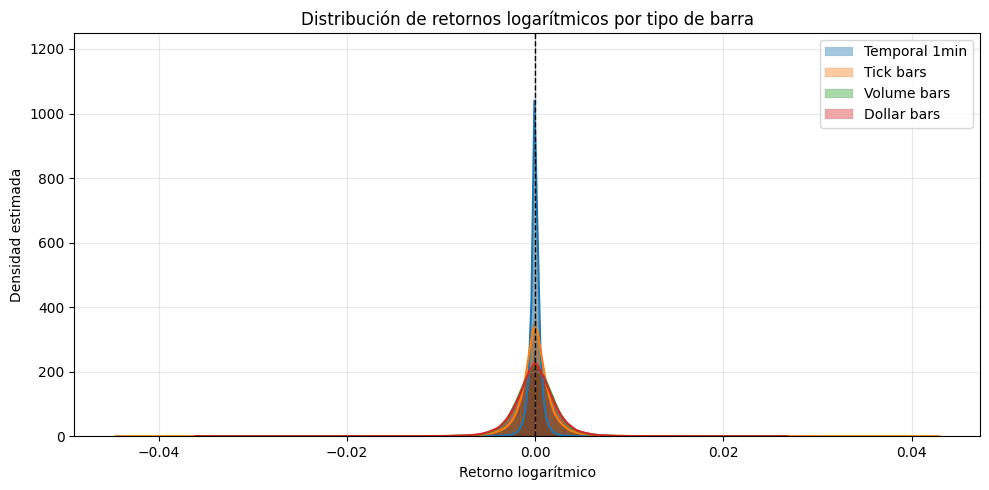

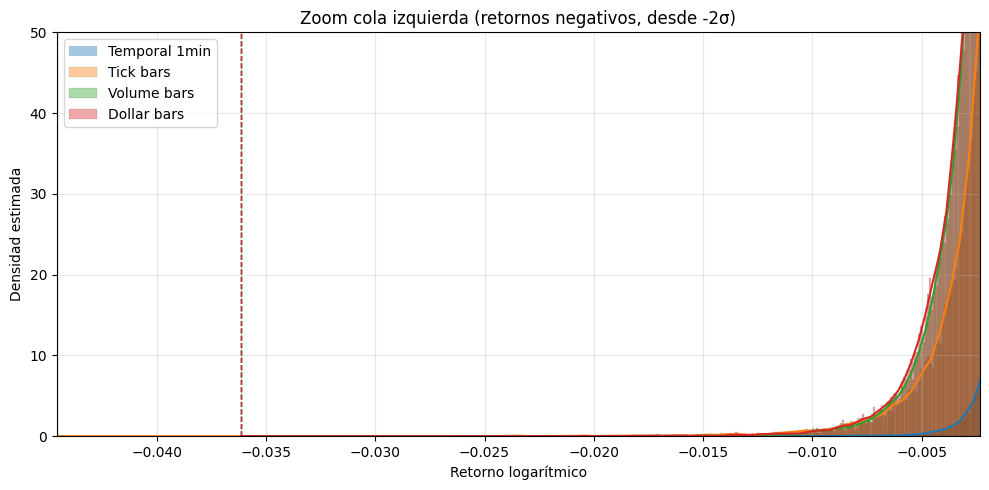

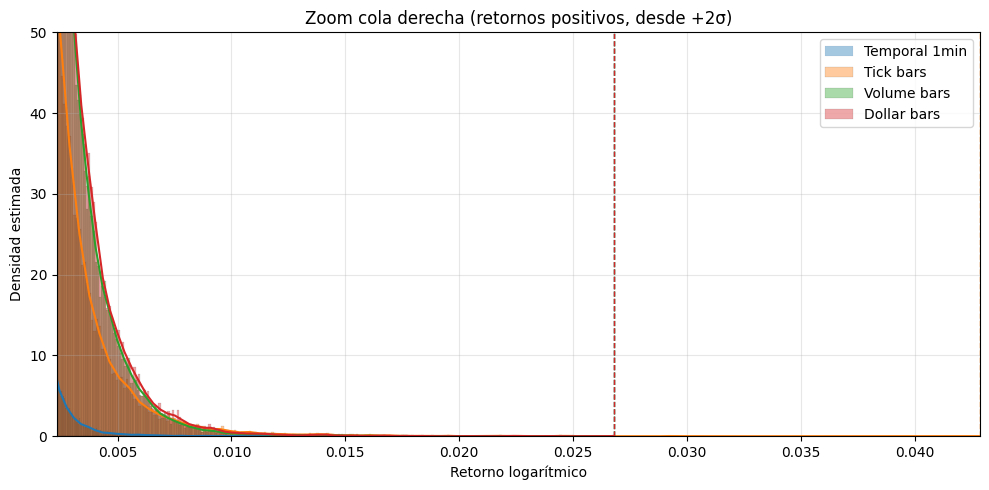

In [110]:
# Filtramos todos los DataFrames al rango de fechas DATE_START → DATE_END
df_temp_plot = df_base.loc[DATE_START:DATE_END]
df_tick_plot = df_tick.loc[DATE_START:DATE_END]
df_volume_plot = df_volume.loc[DATE_START:DATE_END]
df_dollar_plot = df_dollar.loc[DATE_START:DATE_END]

# Cálculo de retornos logarítmicos para cada serie
rets_temporal = np.log(df_temp_plot['close']).diff().dropna()
rets_tick = np.log(df_tick_plot['close']).diff().dropna()
rets_volume = np.log(df_volume_plot['close']).diff().dropna()
rets_dollar = np.log(df_dollar_plot['close']).diff().dropna()

# --- Gráfica 1: distribución completa ---
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(rets_temporal, kde=True, stat='density', label='Temporal 1min', color='tab:blue', alpha=0.4, ax=ax)
sns.histplot(rets_tick, kde=True, stat='density', label='Tick bars', color='tab:orange', alpha=0.4, ax=ax)
sns.histplot(rets_volume, kde=True, stat='density', label='Volume bars', color='tab:green', alpha=0.4, ax=ax)
sns.histplot(rets_dollar, kde=True, stat='density', label='Dollar bars', color='tab:red', alpha=0.4, ax=ax)

ax.set_ylim(0, 1250)  # zoom en Y
ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Distribución de retornos logarítmicos por tipo de barra')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Calculamos media y desviación estándar combinada para determinar los 2σ
all_rets = pd.concat([rets_temporal, rets_tick, rets_volume, rets_dollar])
mean_ret = all_rets.mean()
std_ret = all_rets.std()
two_std = 2 * std_ret

# --- Gráfica 2: zoom cola izquierda (retornos negativos desde -2σ) ---
fig, ax = plt.subplots(figsize=(10, 5))

# Lista de retornos y colores
rets_list = [rets_temporal, rets_tick, rets_volume, rets_dollar]
labels = ['Temporal 1min', 'Tick bars', 'Volume bars', 'Dollar bars']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for rets, label, color in zip(rets_list, labels, colors):
    sns.histplot(rets, kde=True, stat='density', label=label, color=color, alpha=0.4, ax=ax)
    # Línea vertical al final de cada distribución (mínimo para la cola izquierda)
    ax.axvline(rets.min(), color=color, linestyle='--', linewidth=1)

ax.set_xlim(all_rets.min(), mean_ret - two_std)
ax.set_ylim(0, 50)  # zoom en Y
ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Zoom cola izquierda (retornos negativos, desde -2σ)')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Gráfica 3: zoom cola derecha (retornos positivos desde +2σ) ---
fig, ax = plt.subplots(figsize=(10, 5))

for rets, label, color in zip(rets_list, labels, colors):
    sns.histplot(rets, kde=True, stat='density', label=label, color=color, alpha=0.4, ax=ax)
    # Línea vertical al final de cada distribución (máximo para la cola derecha)
    ax.axvline(rets.max(), color=color, linestyle='--', linewidth=1)

ax.set_xlim(mean_ret + two_std, all_rets.max())
ax.set_ylim(0, 50)  # zoom en Y
ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Zoom cola derecha (retornos positivos, desde +2σ)')
ax.set_xlabel('Retorno logarítmico')
ax.set_ylabel('Densidad estimada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6 Analisis ACF

Esta parte calcula la **ACF** (autocorrelación) de los **retornos logarítmicos** para las series construidas con barras `Tick`, `Volume` y `Dollar`. Tiene en cuenta las correlaciones entre $x_t$ y $x_{t-k}$.

- Primero transforma cada serie en **retornos logarítmicos** usando la diferencia entre el logaritmo del precio actual y el del precio anterior.  
- Luego calcula la autocorrelación para distintos retardos (`lags=20`) y grafica los resultados en 3 subgráficos (una curva por tipo de barra).

La finalidad es comprobar si existe **dependencia temporal** en los retornos (si la ACF se desvía claramente de 0 en retardos pequeños), lo que ayuda a entender si la serie es “más o menos” estacionaria o si conserva estructura temporal.

Esto es útil para identificar el **orden de un modelo de medias móviles MA**: si la ACF tiene un pico claro en el retardo q, sugiere que existe un componente MA significativo de orden q.

En este caso, como cabría esperar **los retornos no presentan autocorrelación**, ya que los retornos logarítmicos surgen de la diferencia de los precios logarítmicos inmediatos.

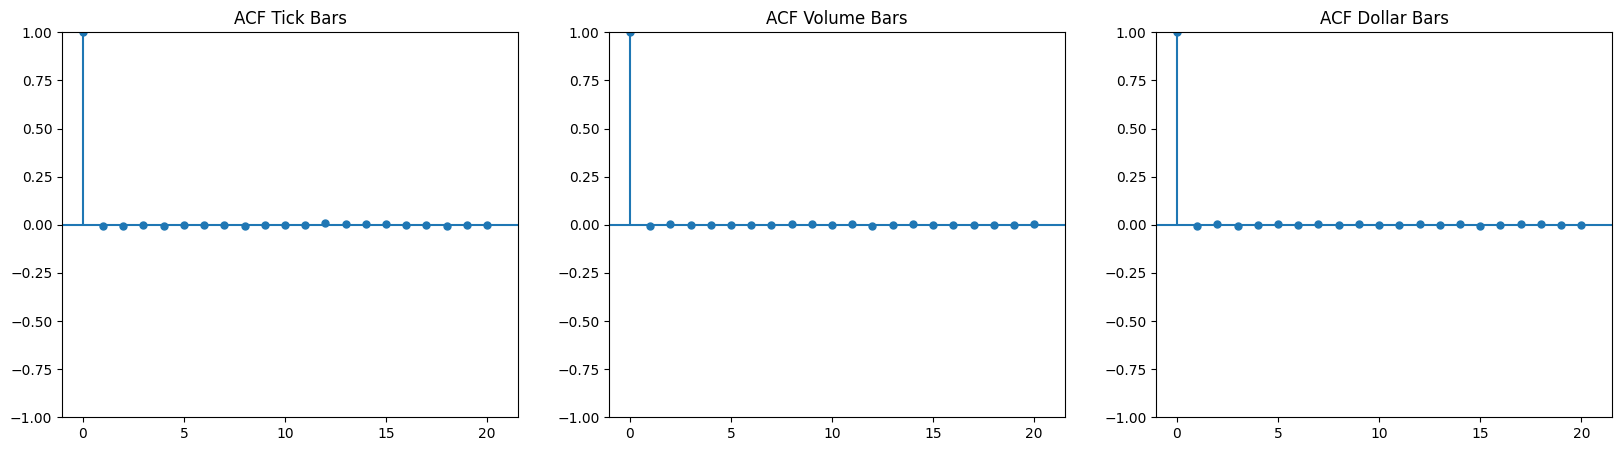

In [111]:
# 1. Calcular log-retornos
# Construimos las tres familias de barras usando solo el DataFrame filtrado

returns_tick = np.log(df_tick['close']).diff().dropna()
returns_vol = np.log(df_volume['close']).diff().dropna()
returns_dollar = np.log(df_dollar['close']).diff().dropna()


fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
series = [returns_tick, returns_vol, returns_dollar]
names = ['Tick', 'Volume', 'Dollar']

for i in range(len(series)):
    plot_acf(series[i], ax=axes[i], lags=20, title=f'ACF {names[i]} Bars')
    #axes[i].set_ylim(-0.1, 0.1) # Zoom para ver pequeñas correlaciones

plt.show()

### 1.7 Analisis PACF

La **PACF** (Partial Autocorrelation Function) mide la correlación parcial entre $x_t$ y $x_{t-k}$, pero **solo** considerando directamente esas dos observaciones.

En otras palabras:
- Para un retardo k, la PACF responde a “cuánto se parece $x_t$ a $x_{t-k}$.
- Pero elimina el efecto que podrían estar explicando los retardos intermedios \(1,2,$\dots$,k-1\).

Esto es útil para identificar el **orden autorregresivo** de un modelo AR: si la PACF tiene un pico claro en el retardo p, sugiere que existe un componente AR significativo de orden p.

En este caso, como cabría esperar **los retornos no presentan autocorrelación parcial**, ya que los retornos logarítmicos surgen de la diferencia de los precios logarítmicos inmediatos.

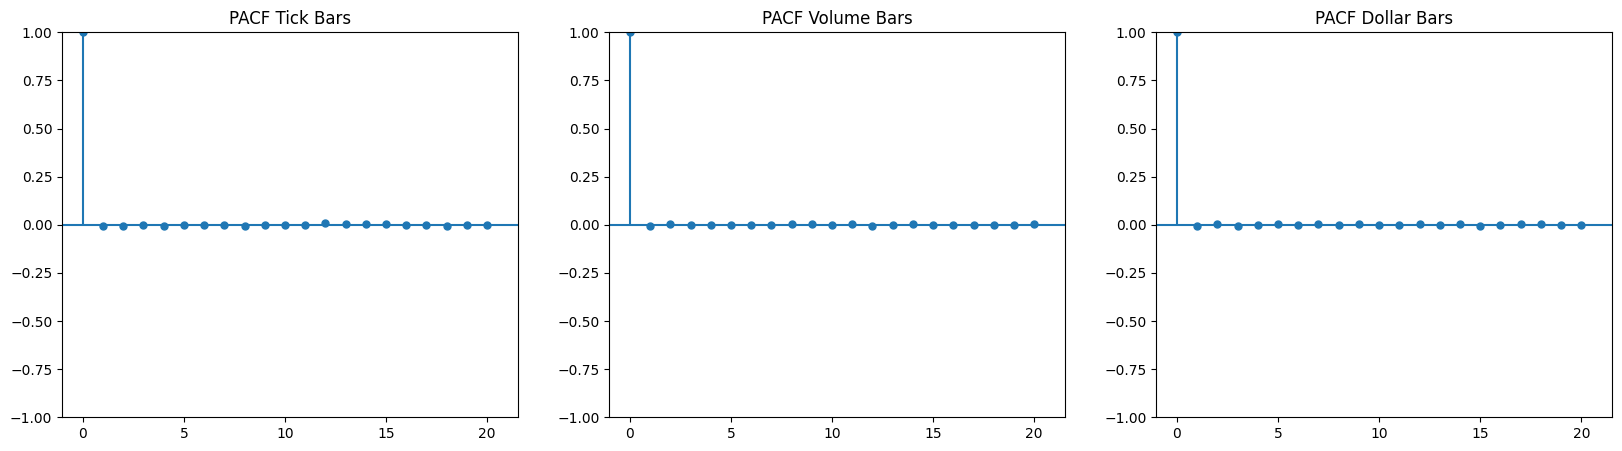

In [112]:
# 1. Calcular log-retornos
# Construimos las tres familias de barras usando solo el DataFrame filtrado

returns_tick = np.log(df_tick['close']).diff().dropna()
returns_vol = np.log(df_volume['close']).diff().dropna()
returns_dollar = np.log(df_dollar['close']).diff().dropna()


fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
series = [returns_tick, returns_vol, returns_dollar]
names = ['Tick', 'Volume', 'Dollar']

for i in range(len(series)):
    plot_pacf(series[i], ax=axes[i], lags=20, title=f'PACF {names[i]} Bars')
    #axes[i].set_ylim(-0.1, 0.1) # Zoom para ver pequeñas correlaciones

plt.show()

### 1.8. Decisión final de la fase: selección de dollar bars

Las gráficas anteriores muestran cómo el número de barras y la forma de las series de precios dependen de la regla de construcción elegida. En general, las tick bars y volume bars ya mitigan en parte la irregularidad de la actividad frente a las barras temporales de 1 minuto, pero las dollar bars homogeneizan explícitamente el capital intercambiado en cada observación.

La comparación de las distribuciones de retornos sugiere que las dollar bars producen retornos con colas menos extremas y una forma más cercana a la normalidad, lo que suele ser deseable en muchos modelos de ML y técnicas estadísticas. Además, al medir la actividad en términos monetarios, las dollar bars son más robustas a cambios en el nivel de precios y en el patrón de volumen.

Siguiendo la recomendación de López de Prado (2018, Cap. 2) y la evidencia visual obtenida, **para el resto del pipeline utilizaremos `df_dollar` como representación base del proceso de precios**, copiándolo a una variable explícita (`df_bars`) que servirá como entrada estándar en las siguientes fases del notebook.

In [113]:

from scipy.stats import skew, kurtosis

# Creamos un diccionario con los retornos
rets_dict = {
    'Temporal 1min': rets_temporal,
    'Tick bars': rets_tick,
    'Volume bars': rets_volume,
    'Dollar bars': rets_dollar
}

# Calculamos estadísticas para cada tipo de barra
stats_list = []
for label, rets in rets_dict.items():
    stats_list.append({
        'Tipo de barra': label,
        'Media': rets.mean(),
        'Desviación estándar': rets.std(),
        'Asimetría (Skewness)': skew(rets),
        'Curtosis': kurtosis(rets)  # Fisher’s definition (0 = normal)
    })

# Convertimos a DataFrame
stats_df = pd.DataFrame(stats_list)

# Mostramos la tabla
pd.set_option('display.float_format', '{:.6f}'.format)
print("Estadísticas de los retornos logarítmicos por tipo de barra:")
display(stats_df)

Estadísticas de los retornos logarítmicos por tipo de barra:


,Tipo de barra,Media,Desviación estándar,Asimetría (Skewness),Curtosis
0,Temporal 1min,0.000001,0.000661,-0.170043,48.484940
1,Tick bars,0.000007,0.002072,-0.261173,23.566800
2,Volume bars,0.000008,0.002220,-0.022702,5.142212
3,Dollar bars,0.000008,0.002302,-0.019962,5.204439


In [27]:
# DataFrame de barras seleccionado para el resto del pipeline

df_bars = df_dollar.copy()

print("df_bars asignado a partir de df_dollar. shape =", df_bars.shape)
print("Rango temporal =", df_bars.index.min(), "→", df_bars.index.max())

df_bars asignado a partir de df_dollar. shape = (128613, 5)
Rango temporal = 2023-02-28 00:00:00 → 2026-02-28 23:48:00


## 2. Diferenciación fraccional de la serie de precios

La diferenciación entera (d=1) elimina completamente la memoria de la serie para lograr estacionariedad, pero destruye información predictiva valiosa. La diferenciación fraccional (0 < d < 1) permite encontrar un equilibrio: series suficientemente estacionarias que conservan memoria a largo plazo, lo cual es crucial para modelos de ML que intentan capturar patrones temporales.

El trade-off fundamental es claro: a mayor valor de d, más estacionaria será la serie pero menos memoria conservará de la serie original. El objetivo práctico es encontrar el mínimo valor de d que logra estacionariedad aceptable, según un test estadístico como el de **Dickey-Fuller** (ADF) sin destruir más memoria de la necesaria.

El algoritmo Fixed-Width Window Fracdiff (FFD) recomendado por López de Prado (2018, Cap. 5) calcula los pesos mediante la fórmula recursiva:

$$w_k = \prod_{i=0}^{k-1} \frac{d - i}{i + 1}$$

donde $w_0 = 1$ y los pesos se truncan cuando su magnitud cae por debajo de un umbral. La serie diferenciada fraccionalmente se obtiene mediante convolución de estos pesos con la serie original.

Técnica (López de Prado): Fixed-Width Window Fractional Differentiation (FFD) para inducir estacionariedad preservando memoria (trade-off (d)).
AFML (2018) — Cap. 5 (Fractionally Differentiated Features).

### 2.1. Parámetros de diferenciación fraccional

En esta celda se definen los parámetros específicos para la Fase 2: los valores de d a explorar, el umbral para truncar pesos pequeños en el algoritmo FFD y el nivel de significancia para el test ADF de estacionariedad.

In [23]:
# ======================================================================
# ### PARÁMETROS FASE 3 ###
# ----------------------------------------------------------------------
# Parámetros para la diferenciación fraccional (Fixed-Width Window FFD).
# - D_VALUES: valores de d a explorar (0.0 = sin diferenciar, 1.0 = diferenciación entera).
# - FRACDIFF_THRESHOLD: umbral para truncar pesos pequeños (cuando |w_k| < threshold).
# - ADF_SIGNIFICANCE: nivel de significancia para el test ADF de estacionariedad.
# ======================================================================
D_VALUES          = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
FRACDIFF_THRESHOLD = 1e-4   # truncación de pesos en el algoritmo FFD
ADF_SIGNIFICANCE   = 0.05   # nivel de significancia para estacionariedad (p < 0.05)

print("Parámetros Fase 3:")
print(f"  D_VALUES          = {D_VALUES}")
print(f"  FRACDIFF_THRESHOLD = {FRACDIFF_THRESHOLD}")
print(f"  ADF_SIGNIFICANCE   = {ADF_SIGNIFICANCE}")

Parámetros Fase 3:
  D_VALUES          = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
  FRACDIFF_THRESHOLD = 0.0001
  ADF_SIGNIFICANCE   = 0.05


### 2.2. Implementación del algoritmo FFD

En esta sección se implementan las dos funciones principales del algoritmo Fixed-Width Window Fracdiff: `get_weights_ffd` (cálculo de pesos recursivos) y `frac_diff_ffd` (aplicación de la convolución sobre la serie). La implementación es manual y explícita para que quede clara la lógica del algoritmo sin depender de librerías externas especializadas.

El algoritmo FFD es preferible a otras variantes porque utiliza una ventana fija de pesos, lo que garantiza estabilidad numérica y permite controlar el número de observaciones iniciales que se pierden por la ventana de convolución.

In [24]:
def get_weights_ffd(d, threshold):
    """Calcula el vector de pesos para diferenciación fraccional usando FFD.

    Los pesos se calculan recursivamente según la fórmula:
        w_0 = 1
        w_k = -w_{k-1} * (d - k + 1) / k

    El cálculo se detiene cuando |w_k| < threshold.

    Parámetros:
    -----------
    d : float
        Grado de diferenciación fraccional (típicamente entre 0 y 1).
    threshold : float
        Umbral mínimo para truncar pesos pequeños.

    Retorna:
    --------
    np.ndarray
        Vector de pesos w_k, donde w[0] = 1.0.
    """
    weights = [1.0]  # w_0 = 1

    k = 1
    while True:
        # Fórmula recursiva: w_k = -w_{k-1} * (d - k + 1) / k
        w_k = -weights[-1] * (d - k + 1) / k

        if abs(w_k) < threshold:
            break

        weights.append(w_k)
        k += 1

    return np.array(weights)

In [25]:
def frac_diff_ffd(series, d, threshold):
    """Aplica diferenciación fraccional usando Fixed-Width Window FFD.

    Para cada punto t de la serie, calcula:
        x_t^d = sum_{k=0}^{l} w_k * x_{t-k}

    donde w_k son los pesos calculados por get_weights_ffd y l es la longitud
    de la ventana (número de pesos no truncados).

    Los primeros l valores de la serie resultante serán NaN porque no hay
    suficientes valores históricos para aplicar la convolución completa.

    Parámetros:
    -----------
    series : pd.Series
        Serie temporal a diferenciar (debe tener índice datetime).
    d : float
        Grado de diferenciación fraccional.
    threshold : float
        Umbral para truncar pesos pequeños.

    Retorna:
    --------
    pd.Series
        Serie diferenciada fraccionalmente, con mismo índice que la entrada.
        Los primeros valores serán NaN debido a la ventana de convolución.
    """
    if d == 0.0:
        # Sin diferenciación: devolver serie original
        return series.copy()

    # Calculamos los pesos
    weights = get_weights_ffd(d, threshold)
    l = len(weights) - 1  # Longitud de la ventana (sin contar w_0)

    # Convertimos la serie a array numpy para la convolución
    values = series.values
    n = len(values)

    # Inicializamos el resultado con NaNs
    result = np.full(n, np.nan)

    # Aplicamos la convolución para cada punto t >= l
    for t in range(l, n):
        # Convolución: sum_{k=0}^{l} w_k * x_{t-k}
        # Nota: w[0] corresponde a w_0, w[1] a w_1, etc.
        conv_sum = 0.0
        for k in range(len(weights)):
            idx = t - k
            if idx >= 0:
                conv_sum += weights[k] * values[idx]
        result[t] = conv_sum

    # Construimos la Serie de salida con el mismo índice
    result_series = pd.Series(result, index=series.index, name=series.name)

    return result_series

### 2.3. Evaluación de múltiples grados de diferenciación y test ADF

En esta sección se aplica la diferenciación fraccional a todos los valores de d especificados en `D_VALUES` y se evalúa cada serie resultante mediante el test Augmented **Dickey-Fuller** (ADF) para determinar su estacionariedad. Además, se calcula la correlación de cada serie diferenciada con la serie original para medir cuánta memoria se preserva.

El objetivo es construir una tabla resumen y seleccionar:

- **($D_{óptimo}$)**: el **menor d** que logra estacionariedad estadística (p-value < 0.05).
- **($D_{alternativo}$)**: un valor de respaldo orientado a **robustez** (p-value más holgado / mejor estabilidad fuera de muestra) cuando el óptimo quede “al límite”.

En esta ventana de **3 años**, ambos criterios coinciden y la selección final queda **$(D_\text{óptimo} = D_\text{alternativo} = 0.4$)**: es a la vez el mínimo d estacionario y el candidato más estable, preservando además alta correlación con la serie original.

In [28]:
# Aplicación de diferenciación fraccional a todos los valores de d

# Verificamos que df_bars está disponible
if 'df_bars' not in globals():
    raise RuntimeError("df_bars no está definido. Ejecute primero la Fase 2 (construcción de barras alternativas).")

# Extraemos la serie de precios de cierre
close_series = df_bars['close'].copy()

print("Serie base para diferenciación fraccional:")
print(f"  Longitud: {len(close_series)} observaciones")
print(f"  Rango temporal: {close_series.index.min()} → {close_series.index.max()}")

# Diccionario para almacenar las series diferenciadas
fracdiff_series = {}

# Lista para almacenar resultados del test ADF
adf_results = []

# Aplicamos diferenciación fraccional para cada valor de d
for d in D_VALUES:
    print(f"\nProcesando d = {d}...")
    series_fd = frac_diff_ffd(close_series, d, FRACDIFF_THRESHOLD)
    fracdiff_series[d] = series_fd

    # Calculamos correlación con la serie original (solo valores no NaN)
    series_fd_clean = series_fd.dropna()
    if len(series_fd_clean) > 0:
        close_clean = close_series.loc[series_fd_clean.index]
        corr = np.corrcoef(close_clean.values, series_fd_clean.values)[0, 1]
    else:
        corr = np.nan

    # Test ADF de estacionariedad (ignorar NaNs)
    series_for_adf = series_fd.dropna()
    if len(series_for_adf) >= 10:  # Mínimo razonable para ADF
        adf_stat, p_value, _, _, adf_critical, _ = adfuller(series_for_adf.values, autolag='AIC')
        is_stationary = p_value < ADF_SIGNIFICANCE
    else:
        adf_stat = np.nan
        p_value = np.nan
        is_stationary = False

    adf_results.append({
        'd': d,
        'adf_stat': adf_stat,
        'p_value': p_value,
        'estacionaria': is_stationary,
        'corr_original': corr
    })

# Construimos DataFrame resumen de resultados ADF
df_adf = pd.DataFrame(adf_results)

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS: Diferenciación fraccional y test ADF")
print("="*70)
display(df_adf)

# ─────────────────────────────────────────────────────────────────────
# Selección del d óptimo con criterio multicriteria
# ─────────────────────────────────────────────────────────────────────
# Criterio principal  : el menor d que logra estacionariedad (p < 0.05)
#                       → garantiza el mínimo de transformación posible
# Criterio alternativo: si d=0.4 también es estacionario y conserva
#                       correlación > 0.75 con la serie original,
#                       se recomienda como alternativa teóricamente
#                       preferible (López de Prado, 2018, Cap. 5)
# ─────────────────────────────────────────────────────────────────────

D_PREFERIDO    = 0.4   # valor de referencia según teoría
CORR_MIN       = 0.75  # correlación mínima para considerar d=0.4 válido

df_adf_valid = df_adf[df_adf['estacionaria'] == True]

if not df_adf_valid.empty:
    # Criterio mínimo: d más pequeño que logra estacionariedad
    D_OPTIMO = df_adf_valid['d'].min()

    # Verificar si d=0.4 también es válido como alternativa preferida
    row_04 = df_adf[df_adf['d'] == D_PREFERIDO]
    if (not row_04.empty
            and row_04['estacionaria'].values[0]
            and row_04['corr_original'].values[0] >= CORR_MIN):
        D_ALTERNATIVO = D_PREFERIDO
    else:
        D_ALTERNATIVO = D_OPTIMO  # Si 0.4 no cumple, coinciden
else:
    # Fallback: sin ningún d estacionario → el de menor p-value
    print("\nAdvertencia: ningún valor de d logra estacionariedad según el test ADF.")
    df_adf_with_pval = df_adf.dropna(subset=['p_value'])
    D_OPTIMO      = df_adf_with_pval.loc[df_adf_with_pval['p_value'].idxmin(), 'd']
    D_ALTERNATIVO = D_OPTIMO
    print(f"D_OPTIMO seleccionado (fallback): {D_OPTIMO}")

# ─────────────────────────────────────────────────────────────────────
# Tabla comparativa D_OPTIMO vs D_ALTERNATIVO
# ─────────────────────────────────────────────────────────────────────
candidates = sorted(set([D_OPTIMO, D_ALTERNATIVO]))
df_comp = df_adf[df_adf['d'].isin(candidates)].copy()
df_comp = df_comp.set_index('d')

print("\n" + "="*70)
print("TABLA COMPARATIVA DE CANDIDATOS DE d")
print("="*70)
print(df_comp[['adf_stat', 'p_value', 'estacionaria', 'corr_original']].to_string())
print()

# Resumen narrativo
for d_val in candidates:
    row = df_adf[df_adf['d'] == d_val].iloc[0]
    tag = " <-- D_OPTIMO (mínimo estacionario)" if d_val == D_OPTIMO else ""
    tag += " <-- D_ALTERNATIVO (equilibrio teórico)" if d_val == D_ALTERNATIVO and d_val != D_OPTIMO else ""
    print(f"  d={d_val:.1f} | p-value={row['p_value']:.6f} | corr={row['corr_original']:.4f}{tag}")

print()
print(f"D_OPTIMO      = {D_OPTIMO}  (criterio: menor d estacionario)")
if D_ALTERNATIVO != D_OPTIMO:
    print(f"D_ALTERNATIVO = {D_ALTERNATIVO}  (criterio: equilibrio memoria/estacionariedad)")
    print("  → Para mayor robustez estadística se recomienda D_ALTERNATIVO=0.4")

Serie base para diferenciación fraccional:
  Longitud: 128613 observaciones
  Rango temporal: 2023-02-28 00:00:00 → 2026-02-28 23:48:00

Procesando d = 0.0...

Procesando d = 0.2...

Procesando d = 0.4...

Procesando d = 0.6...

Procesando d = 0.8...

Procesando d = 1.0...

RESUMEN DE RESULTADOS: Diferenciación fraccional y test ADF


,d,adf_stat,p_value,estacionaria,corr_original
0,0.0,-2.023838,2.762197e-01,False,1.000000
1,0.2,-2.482053,1.199022e-01,False,0.998515
2,0.4,-3.333447,1.344802e-02,True,0.990456
3,0.6,-4.641400,1.082797e-04,True,0.954542
4,0.8,-6.952400,9.617806e-10,True,0.778818
5,1.0,-207.980862,0.000000e+00,True,0.000557



TABLA COMPARATIVA DE CANDIDATOS DE d
     adf_stat   p_value  estacionaria  corr_original
d                                                   
0.4 -3.333447  0.013448          True       0.990456

  d=0.4 | p-value=0.013448 | corr=0.9905 <-- D_OPTIMO (mínimo estacionario)

D_OPTIMO      = 0.4  (criterio: menor d estacionario)


### 2.4. Visualización de resultados de diferenciación fraccional

En esta sección se generan dos gráficas complementarias que facilitan la interpretación de los resultados de la diferenciación fraccional:

1) las series diferenciadas superpuestas para cada valor de d
2) la evolución de la correlación con la serie original en función de d

Estas visualizaciones permiten verificar visualmente la estacionariedad de las series, entender el trade-off entre memoria y estacionariedad y confirmar la selección del d óptimo basado en criterios estadísticos objetivos.

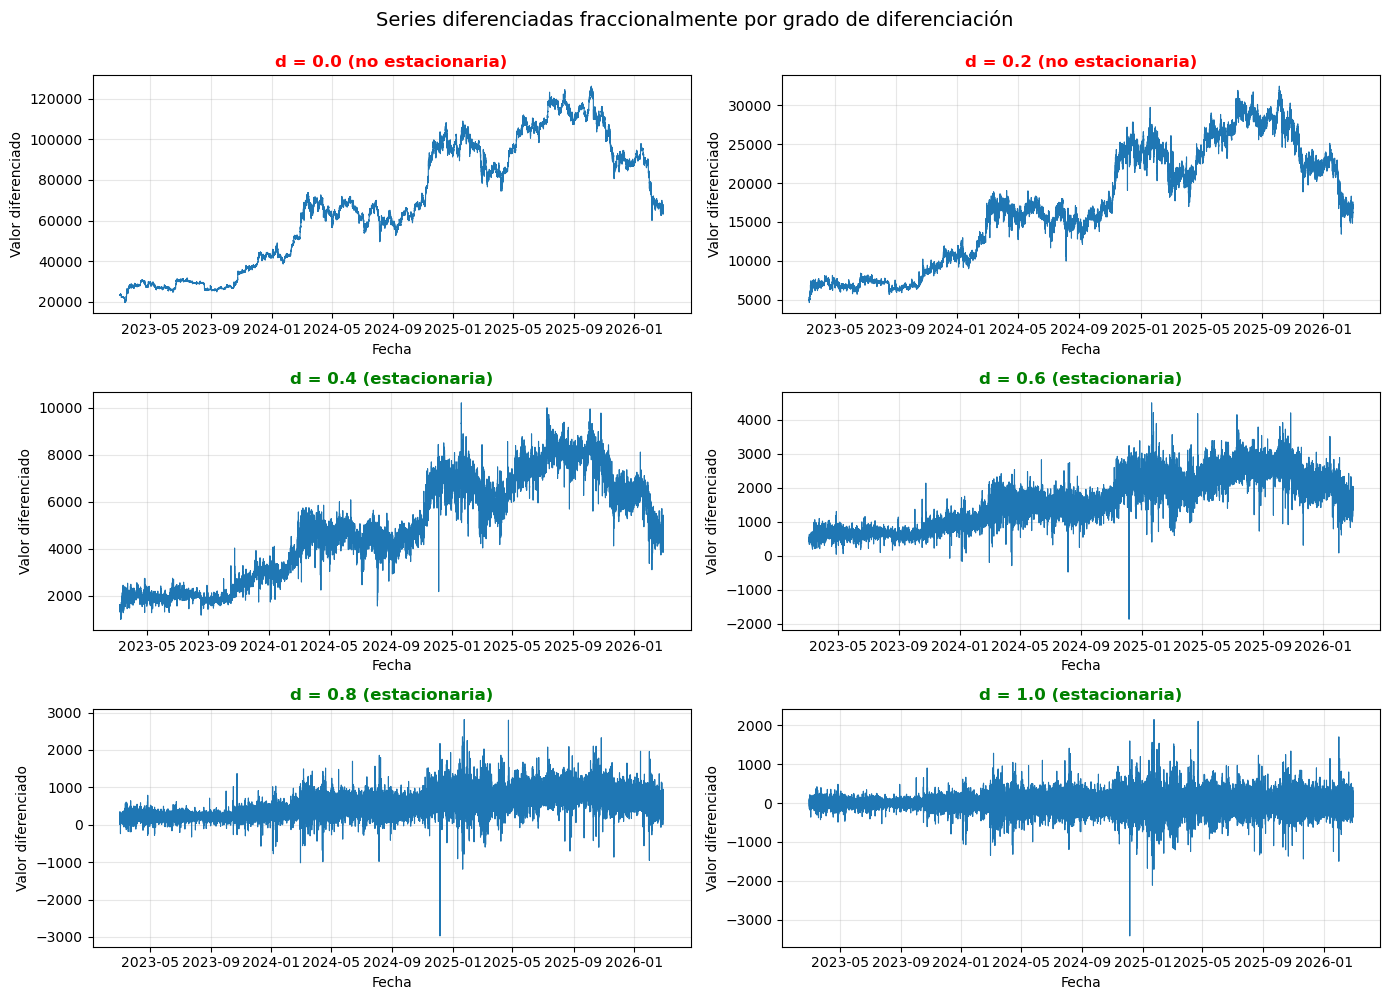

In [29]:
# Gráfica 1: series diferenciadas superpuestas (una por valor de d)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, d in enumerate(D_VALUES):
    ax = axes[idx]
    series_fd = fracdiff_series[d]

    # Plot de la serie diferenciada
    ax.plot(series_fd.index, series_fd.values, color='tab:blue', linewidth=0.8)

    # Título con indicación de estacionariedad
    is_stationary = df_adf[df_adf['d'] == d]['estacionaria'].values[0]
    if is_stationary:
        title_color = 'green'
        status_text = " (estacionaria)"
    else:
        title_color = 'red'
        status_text = " (no estacionaria)"

    ax.set_title(f"d = {d}{status_text}", color=title_color, fontweight='bold')
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor diferenciado")
    ax.grid(alpha=0.3)

fig.suptitle('Series diferenciadas fraccionalmente por grado de diferenciación', y=0.995, fontsize=14)
plt.tight_layout()

plt.show()

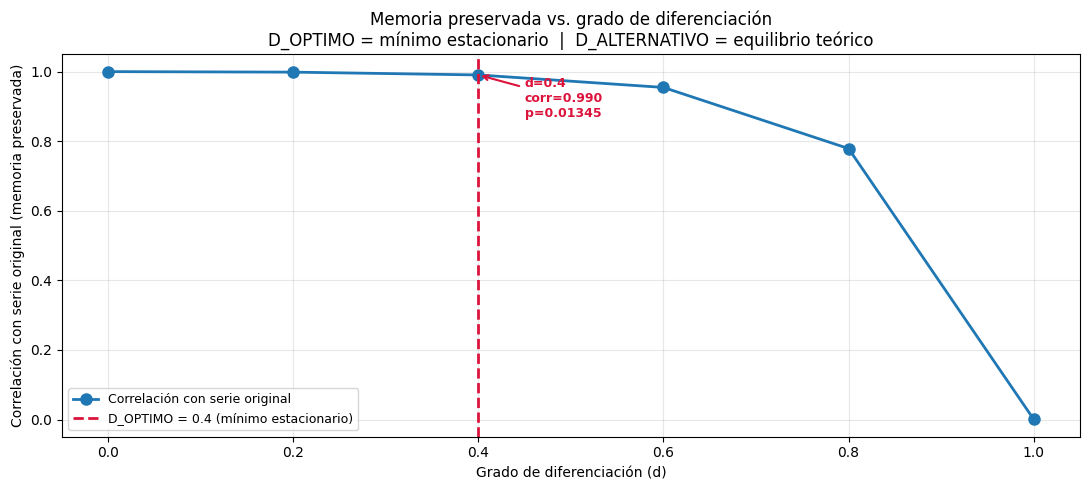

In [120]:
# Gráfica 2: correlación con serie original vs. grado de diferenciación d
# Se marcan tanto D_OPTIMO (mínimo estacionario) como D_ALTERNATIVO (equilibrio teórico)

fig, ax = plt.subplots(figsize=(11, 5))

d_vals   = df_adf['d'].values
corr_vals = df_adf['corr_original'].values

ax.plot(d_vals, corr_vals, marker='o', linewidth=2, markersize=8,
        color='tab:blue', label='Correlación con serie original')

# ── Línea vertical D_OPTIMO (criterio mínimo) ──────────────────────────────
ax.axvline(D_OPTIMO, color='crimson', linestyle='--', linewidth=2,
           label=f'D_OPTIMO = {D_OPTIMO} (mínimo estacionario)')

opt_row  = df_adf[df_adf['d'] == D_OPTIMO].iloc[0]
opt_corr = opt_row['corr_original']
ax.annotate(
    f'd={D_OPTIMO}\ncorr={opt_corr:.3f}\np={opt_row["p_value"]:.5f}',
    xy=(D_OPTIMO, opt_corr),
    xytext=(D_OPTIMO + 0.05, opt_corr - 0.12),
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5),
    fontsize=9, color='crimson', fontweight='bold'
)

# ── Línea vertical D_ALTERNATIVO (equilibrio teórico) ──────────────────────
if D_ALTERNATIVO != D_OPTIMO:
    ax.axvline(D_ALTERNATIVO, color='darkorange', linestyle=':', linewidth=2,
               label=f'D_ALTERNATIVO = {D_ALTERNATIVO} (equilibrio teórico)')

    alt_row  = df_adf[df_adf['d'] == D_ALTERNATIVO].iloc[0]
    alt_corr = alt_row['corr_original']
    ax.annotate(
        f'd={D_ALTERNATIVO}\ncorr={alt_corr:.3f}\np={alt_row["p_value"]:.6f}',
        xy=(D_ALTERNATIVO, alt_corr),
        xytext=(D_ALTERNATIVO + 0.05, alt_corr + 0.04),
        arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.5),
        fontsize=9, color='darkorange', fontweight='bold'
    )

# ── Zona sombreada entre los dos candidatos ────────────────────────────────
if D_ALTERNATIVO != D_OPTIMO:
    ax.axvspan(D_OPTIMO, D_ALTERNATIVO, alpha=0.08, color='gold',
               label='Zona de interés (trade-off)')

ax.set_xlabel('Grado de diferenciación (d)')
ax.set_ylabel('Correlación con serie original (memoria preservada)')
ax.set_title('Memoria preservada vs. grado de diferenciación\n'
             'D_OPTIMO = mínimo estacionario  |  D_ALTERNATIVO = equilibrio teórico')
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5. Comparacion directa: $D_{OPTIMO}$ vs $D_{ALTERNATIVO}$

La siguiente grafica muestra lado a lado la serie diferenciada con `D_OPTIMO` (criterio automatico de minimo d estacionario) y con `D_ALTERNATIVO = 0.4` (criterio de equilibrio teorico segun Lopez de Prado). El objetivo es que el usuario pueda evaluar visualmente el trade-off entre maxima memoria preservada y mayor robustez estadistica antes de tomar la decision final.

In [121]:
# Gráfica comparativa: D_OPTIMO vs D_ALTERNATIVO lado a lado
# Muestra visualmente el trade-off: memoria preservada (D_OPTIMO) vs
# robustez estadística (D_ALTERNATIVO).

if D_ALTERNATIVO != D_OPTIMO:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    for ax, d_val, color, label in [
        (axes[0], D_OPTIMO,      'crimson',    f'd = {D_OPTIMO}  — D_OPTIMO\n(mínimo estacionario, máxima memoria)'),
        (axes[1], D_ALTERNATIVO, 'darkorange', f'd = {D_ALTERNATIVO}  — D_ALTERNATIVO\n(equilibrio teórico, mayor robustez)'),
    ]:
        serie = fracdiff_series[d_val].dropna()
        ax.plot(serie.index, serie.values, color=color, linewidth=0.8)

        row = df_adf[df_adf['d'] == d_val].iloc[0]
        ax.set_title(
            f'{label}\n'
            f'corr original = {row["corr_original"]:.4f}  |  '
            f'p-value ADF = {row["p_value"]:.6f}',
            color=color, fontsize=9
        )
        ax.set_xlabel('Fecha')
        ax.set_ylabel('Valor diferenciado')
        ax.grid(alpha=0.3)

    fig.suptitle(
        'Trade-off memoria vs. robustez estadística\n'
        'Comparación directa entre los dos candidatos de d',
        fontsize=12
    )
    plt.tight_layout()

else:
    print("D_OPTIMO y D_ALTERNATIVO coinciden; no se genera gráfica comparativa.")

D_OPTIMO y D_ALTERNATIVO coinciden; no se genera gráfica comparativa.


### 2.6. Decisión final de la fase: selección del grado de diferenciación fraccional

Las gráficas anteriores proporcionan evidencia complementaria para la selección del grado de diferenciación fraccional.
1) La primera (series superpuestas) muestra cómo cambia la forma de la serie al variar d.
2) La segunda (correlación vs d) ilustra el trade-off entre memoria preservada y estacionariedad.
3) La tercera compara directamente las series resultantes.

**Resultado con la ventana actual (3 años): un único candidato consistente**

En esta muestra, el test ADF indica que **d = 0.2 no alcanza estacionariedad** (p-value ≥ 0.05), mientras que **d = 0.4 sí es estacionario** (p-value < 0.05) manteniendo además una correlación alta con la serie original. Por tanto, el criterio “mínimo d estacionario” y el criterio “equilibrio teórico” **coinciden**:

| Criterio | d | p-value ADF | Correlación con original | Interpretación |
|---|---|---|---|---|
| Mínimo d estacionario (ADF) | **D_OPTIMO = 0.4** | ≈ 0.013 | ≈ 0.990 | Estacionariedad alcanzada con transformación mínima |
| Equilibrio teórico (López de Prado) | **D_ALTERNATIVO = 0.4** | ≈ 0.013 | ≈ 0.990 | Coincide con el mínimo estacionario en esta muestra |

**Por qué aquí no hay “óptimo vs alternativo”**
La distinción entre `D_OPTIMO` y `D_ALTERNATIVO` se mantiene como convención del pipeline (en otras ventanas/activos pueden diferir), pero en esta ventana de 3 años ambos apuntan al mismo valor. Esto es coherente con la teoría: al ampliar la muestra aparecen regímenes adicionales y persistencia más estable, y el mínimo d que satisface estacionariedad puede desplazarse hacia valores alrededor de 0.4.

**Recomendación**
- Para esta muestra: continuar con **d = 0.4** (no hay trade-off entre memoria y estacionariedad porque ambos criterios coinciden).
- Mantener `D_OPTIMO` y `D_ALTERNATIVO` en el código por trazabilidad, aunque aquí sean iguales.

In [122]:
# ─────────────────────────────────────────────────────────────────────────────
# Serie diferenciada fraccionalmente seleccionada para el resto del pipeline.
# ─────────────────────────────────────────────────────────────────────────────

# Cambiar D_ALTERNATIVO → D_OPTIMO para usar la alternativa 
D_SELECCIONADO = D_ALTERNATIVO   # <── modificar aquí si se prefiere D_OPTIMO

close_fd = fracdiff_series[D_SELECCIONADO].dropna()

row_sel = df_adf[df_adf['d'] == D_SELECCIONADO].iloc[0]
print("=" * 60)
print("Serie diferenciada fraccionalmente seleccionada (close_fd):")
print(f"  d utilizado          : {D_SELECCIONADO}")
print(f"  Longitud (tras dropna): {len(close_fd)} observaciones")
print(f"  Rango temporal        : {close_fd.index.min()} -> {close_fd.index.max()}")
print(f"  Correlacion c/ original: {row_sel['corr_original']:.4f}")
print(f"  p-value ADF           : {row_sel['p_value']:.6f}")
print(f"  Estacionaria (p < {ADF_SIGNIFICANCE}): {row_sel['estacionaria']}")

if D_ALTERNATIVO != D_OPTIMO:
    row_alt = df_adf[df_adf['d'] == D_OPTIMO].iloc[0]
    print()
    print(f"  (Alternativa disponible: D_OPTIMO = {D_OPTIMO}  |"
          f"  corr={row_alt['corr_original']:.4f}  |  p={row_alt['p_value']:.6f})")

print("=" * 60)
print("\nclose_fd esta lista para ser utilizada en las siguientes fases del pipeline.")

Serie diferenciada fraccionalmente seleccionada (close_fd):
  d utilizado          : 0.4
  Longitud (tras dropna): 128332 observaciones
  Rango temporal        : 2023-03-08 00:01:00 -> 2026-02-28 23:48:00
  Correlacion c/ original: 0.9905
  p-value ADF           : 0.013448
  Estacionaria (p < 0.05): True

close_fd esta lista para ser utilizada en las siguientes fases del pipeline.


## 3. Construcción y limpieza de la matriz de covarianza

En esta fase aplicamos *covariance cleaning* sobre el parquet wide: construimos retornos, estimamos la covarianza empírica y la eliminamos el ruido separando señal vs ruido con **Marchenko–Pastur + eigenvalue clipping**, siguiendo el enfoque de **López de Prado (MLAM 2020)**.

Leemos los datos de las cotizaciones de las siguientes 10 criptomonedas (en dólares):
- **ADAUSDT**: Cardano
- **BNBUSDT**: BNB
- **BTCUSDT**: Bitcoin
- **DOGEUSDT**: Dogecoin
- **DOTUSDT**: Polkadot
- **ETHUSDT**: Ethereum
- **LINKUSDT**: Chainlink
- **LTCUSDT**: Litecoin
- **SOLUSDT**: Solana
- **XRPUSDT**: XRP

In [16]:
DATA_PATH = "data/datos_crypto_limpios.parquet"

df_ej3 = pd.read_parquet(DATA_PATH)
df_ej3.head()

,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,DOTUSDT,ETHUSDT,LINKUSDT,LTCUSDT,SOLUSDT,XRPUSDT
2020-08-18 23:00:00,0.13703,23.0786,12026.09,0.003518,2.9999,423.96,16.2455,66.21,3.3926,0.30279
2020-08-18 23:05:00,0.13724,23.0964,12034.70,0.003520,2.9261,424.56,16.2455,66.31,3.3850,0.30349
2020-08-18 23:10:00,0.13693,23.0214,12014.55,0.003505,2.9999,423.32,16.1453,66.00,3.4066,0.30252
2020-08-18 23:15:00,0.13707,23.0280,12018.19,0.003512,2.9729,423.51,16.2096,66.12,3.4023,0.30277
2020-08-18 23:20:00,0.13702,23.0327,12001.51,0.003503,3.0100,423.03,16.1805,66.01,3.4000,0.30267


#### 3.1 Funciones auxiliares

Este bloque centraliza la parte “espectral” siguiendo el enfoque de **López de Prado** para *covariance/correlation cleaning* con **Marchenko–Pastur (RMT)**:

- `get_pca(matrix)`: obtiene autovalores/autovectores ordenados (descomposición espectral) para trabajar con el espectro de la matriz.
- `denoise_matrix_mp(corr_matrix, T, N)`: aplica **denoising MP** sobre la matriz de correlación:
  - calcula el umbral teórico de Marchenko–Pastur (`e_max`) bajo el supuesto de “bulk ruido” (σ²=1 para correlación),
  - separa autovalores de **señal** vs **ruido**,
  - aplica el esquema **“Constant Residual”** sustituyendo los autovalores del ruido por un único valor (promedio del bulk),
  - reconstruye la matriz limpia y reescala para mantener la diagonal en 1.
  
El resultado es una correlación “limpia” que luego se usa en la reconstrucción/visualización de covarianza mas adelante

In [17]:
# ==========================================
# BLOQUE 1: Funciones Auxiliares (López de Prado)
# ==========================================

def get_pca(matrix):
    """Obtiene autovalores y autovectores ordenados de forma descendente."""
    e_val, e_vec = np.linalg.eigh(matrix)
    indices = e_val.argsort()[::-1] # Orden descendente
    e_val, e_vec = e_val[indices], e_vec[:, indices]
    e_val = np.diagflat(e_val)
    return e_val, e_vec

def denoise_matrix_mp(corr_matrix, T, N):
    """
    Limpia la matriz de correlación eliminando el ruido usando el método
    'Constant Residual' de Marchenko-Pastur.
    """
    if isinstance(corr_matrix, pd.DataFrame):
        corr_matrix = corr_matrix.values
        
    q = T / N
    e_val, e_vec = get_pca(corr_matrix)
    e_val_diag = np.diag(e_val)
    
    # 1. Encontrar el límite de Marchenko-Pastur (sigma^2=1 para correlación)
    sigma_sq = 1.0 
    e_max = sigma_sq * (1 + (1./q)**0.5)**2
    
    # 2. Identificar autovalores de señal vs ruido
    n_facts = e_val_diag[e_val_diag > e_max].shape[0]
    
    # 3. Aplicar "Constant Residual": Sustituir ruidosos por su promedio
    e_val_denoised = e_val_diag.copy()
    media_ruido = e_val_diag[n_facts:].sum() / float(e_val_diag.shape[0] - n_facts)
    e_val_denoised[n_facts:] = media_ruido
    
    # 4. Reconstruir la matriz de correlación
    corr_denoised = np.dot(e_vec, np.dot(np.diag(e_val_denoised), e_vec.T))
    
    # 5. Re-escalar para asegurar que la diagonal vuelva a ser 1s
    d = np.diag(corr_denoised)
    std = np.sqrt(d)
    corr_denoised /= np.outer(std, std)
    
    return corr_denoised, e_max, e_val_diag

#### 3.2 Ejecucion de limpieza

Calcula retornos log (`df_returns`) y sus tamaños efectivos (`T, N`), estima `cov_ruidosa`/`corr_ruidosa`, y aplica **covariance/correlation cleaning** con **Marchenko–Pastur + denoising** (`denoise_matrix_mp`).  
Finalmente reconstruye la **covarianza limpia** reescalando la correlación limpia con las volatilidades originales para obtener `cov_limpia_df` (y `corr_limpia_df`).

In [18]:
# ==========================================
# BLOQUE 2: Ejecución del Ejercicio 3
# ==========================================

print("--- PASO 1: Calcular Retornos Logarítmicos ---")
# Usamos retornos logarítmicos para estacionarizar y normalizar
df_returns = np.log(df_ej3).diff().dropna()
T, N = df_returns.shape
print(f"Dimensiones de los retornos: {T} filas (observaciones), {N} columnas (activos)")

print("\n--- PASO 2: Calcular Matrices Originales ---")
cov_ruidosa = df_returns.cov()
corr_ruidosa = df_returns.corr()
# Guardamos las desviaciones típicas (volatilidad) originales
std_originales = np.sqrt(np.diag(cov_ruidosa))

print("\n--- PASO 3: Limpieza de la Correlación (Denoising) ---")
# Aplicamos la limpieza a la matriz de correlación
corr_limpia_arr, e_max, e_val_orig_vector = denoise_matrix_mp(corr_ruidosa, T, N)
corr_limpia_df = pd.DataFrame(corr_limpia_arr, index=corr_ruidosa.index, columns=corr_ruidosa.columns)

print("\n--- PASO 4: Reconstruir la Covarianza Limpia ---")
# Re-escalamos la correlación limpia usando las volatilidades originales
# Cov = diag(std) * Corr * diag(std)
cov_limpia_arr = np.outer(std_originales, std_originales) * corr_limpia_arr
cov_limpia_df = pd.DataFrame(cov_limpia_arr, index=cov_ruidosa.index, columns=cov_ruidosa.columns)

print("\n--- PROCESO COMPLETADO ---")
print("Matrices calculadas: 'cov_limpia_df' y 'corr_limpia_df'")

--- PASO 1: Calcular Retornos Logarítmicos ---
Dimensiones de los retornos: 581488 filas (observaciones), 10 columnas (activos)

--- PASO 2: Calcular Matrices Originales ---

--- PASO 3: Limpieza de la Correlación (Denoising) ---

--- PASO 4: Reconstruir la Covarianza Limpia ---

--- PROCESO COMPLETADO ---
Matrices calculadas: 'cov_limpia_df' y 'corr_limpia_df'


#### 3.3 Graficos

Este bloque visualiza el efecto del **cleaning Marchenko–Pastur**:

- **Plot de autovalores**: compara el espectro “ruidoso” (`e_val_orig_vector`) vs el espectro **denoised** (autovalores de `corr_limpia_arr`) y marca el umbral `e_max` de Marchenko–Pastur.  
- **Heatmap de correlación**: `corr_ruidosa` vs `corr_limpia_df` para confirmar que el bulk de ruido se reduce manteniendo la estructura relevante.
- **Heatmap de covarianza**: `cov_ruidosa` vs `cov_limpia_df` para verificar que la covarianza limpia refleja esa estabilización.

Finalmente, reporta el **número de condición** (`cond_orig` vs `cond_limpia`) como medida simple de la mejora de **estabilidad numérica** tras el denoising 


--- PASO 5: Generar Gráficos ---


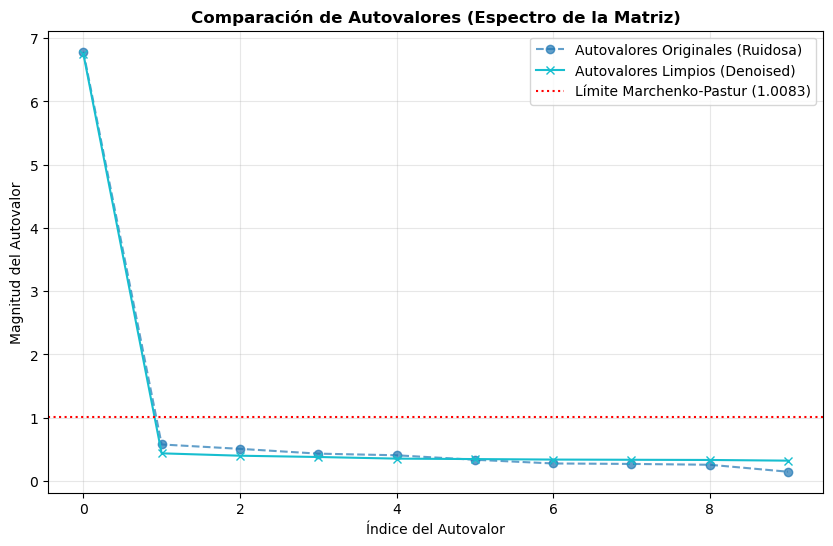

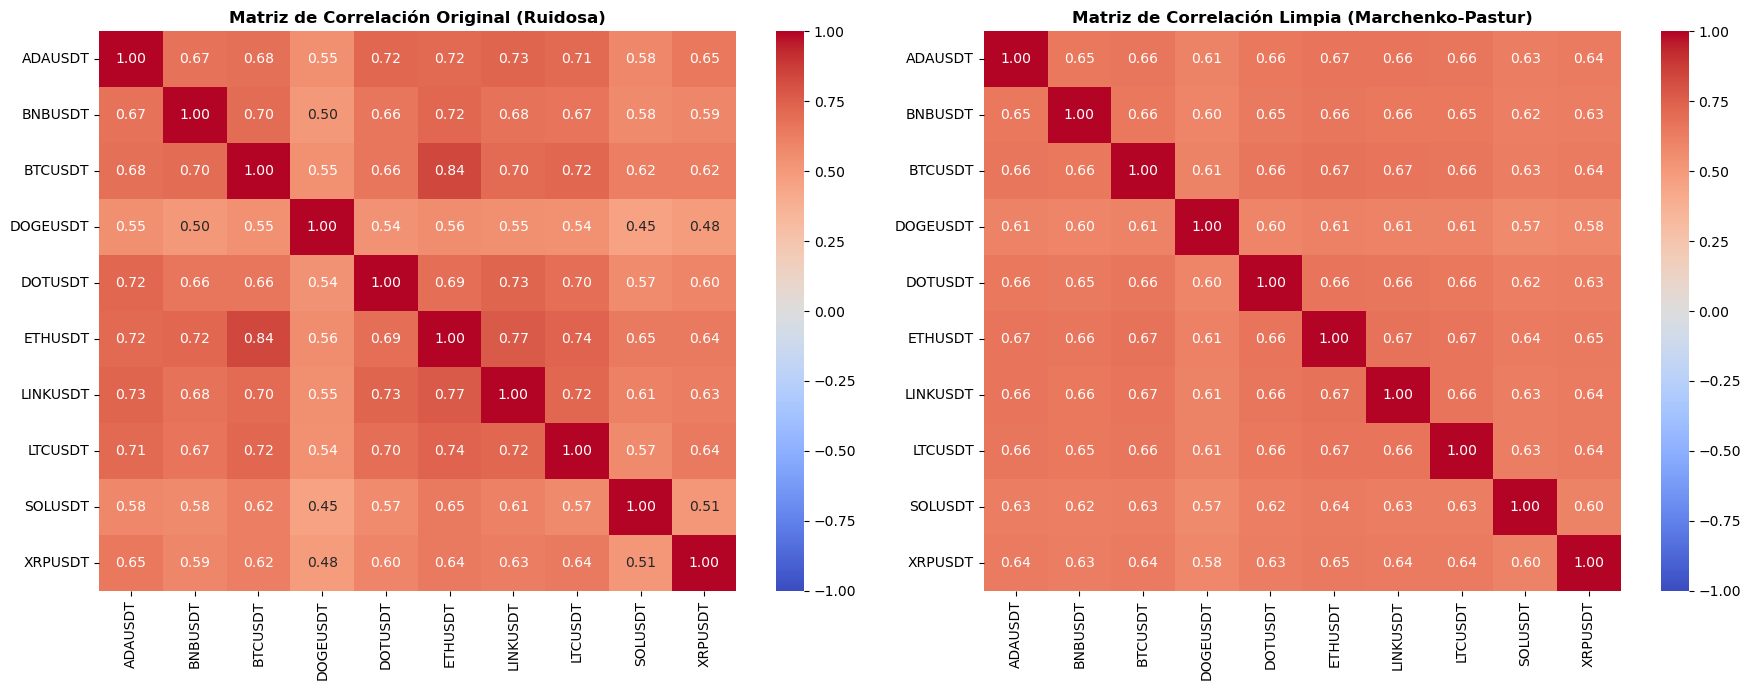

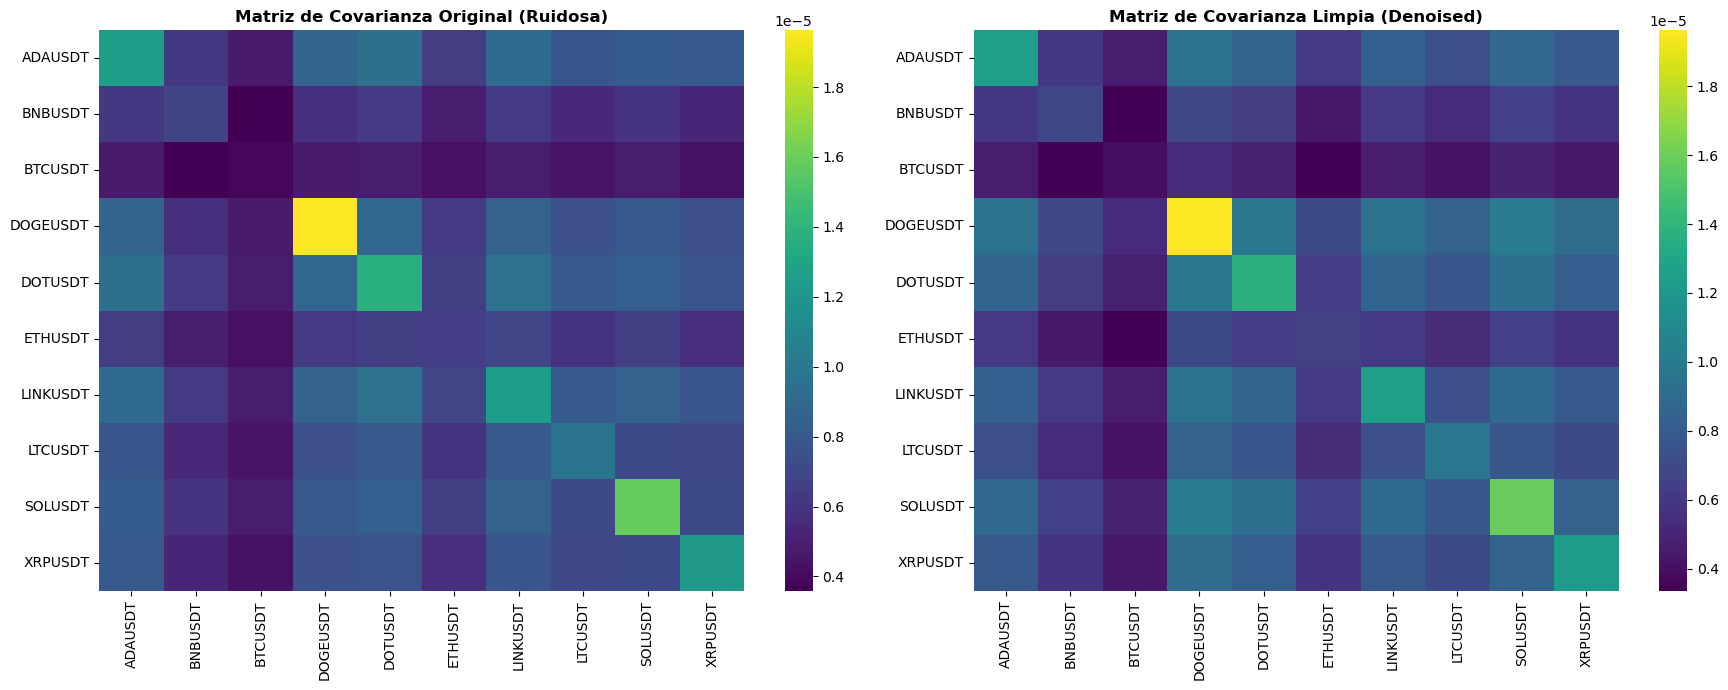


Número de Condición Original: 100.19
Número de Condición Limpia:   55.17
Mejora de estabilidad numérica: 81.61%


In [20]:
# ==========================================
# BLOQUE 3: Gráficos y Visualización
# ==========================================

print("\n--- PASO 5: Generar Gráficos ---")

# Gráfico 1: Espectro de Autovalores (Scree Plot)
# Extraemos los autovalores y aseguramos que sean vectores 1D ordenados
e_val_orig_vector_sorted = np.sort(e_val_orig_vector)[::-1]
# Para la matriz limpia, recalculamos para asegurar que el vector sea 1D y esté ordenado
e_val_limp_raw = np.linalg.eigvals(corr_limpia_arr)
e_val_limpia_vector = np.sort(e_val_limp_raw)[::-1]

plt.figure(figsize=(10, 6))

# Al pasar vectores 1D, Matplotlib solo genera UNA entrada en la leyenda por cada .plot()
plt.plot(e_val_orig_vector_sorted, label='Autovalores Originales (Ruidosa)', 
         marker='o', ls='--', color='tab:blue', alpha=0.7)

plt.plot(e_val_limpia_vector, label='Autovalores Limpios (Denoised)', 
         marker='x', ls='-', color='tab:cyan')

plt.axhline(y=e_max, color='r', linestyle=':', label=f'Límite Marchenko-Pastur ({e_max:.4f})')

plt.title("Comparación de Autovalores (Espectro de la Matriz)", fontweight='bold')
plt.ylabel("Magnitud del Autovalor")
plt.xlabel("Índice del Autovalor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfico 2: Heatmaps Comparativos de Correlación
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_ruidosa, ax=ax[0], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
ax[0].set_title("Matriz de Correlación Original (Ruidosa)", fontweight='bold')

sns.heatmap(corr_limpia_df, ax=ax[1], annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
ax[1].set_title("Matriz de Correlación Limpia (Marchenko-Pastur)", fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico 3: Heatmaps Comparativos de COVARIANZA
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cov_ruidosa, ax=ax[0], annot=False, cmap='viridis')
ax[0].set_title("Matriz de Covarianza Original (Ruidosa)", fontweight='bold')

sns.heatmap(cov_limpia_df, ax=ax[1], annot=False, cmap='viridis')
ax[1].set_title("Matriz de Covarianza Limpia (Denoised)", fontweight='bold')
plt.tight_layout()
plt.show()

# Opcional: Dato numérico de mejora de estabilidad
cond_orig = np.linalg.cond(cov_ruidosa)
cond_limpia = np.linalg.cond(cov_limpia_df)
print(f"\nNúmero de Condición Original: {cond_orig:.2f}")
print(f"Número de Condición Limpia:   {cond_limpia:.2f}")
print(f"Mejora de estabilidad numérica: {((cond_orig/cond_limpia)-1)*100:.2f}%")

En este caso, hemos trabajado con datos de 10 criptomonedas desde 2020 hasta febrero de 2026. Los datos tienen una temporalidad de cinco minutos.

Gracias a descomposición de la matriz de retornos a través del análisis de componentes principales, obtenemos sus valores y vectores propios. El umbral a partir del cual consideraremos un valor propio como significativo e informativo es aquel que sea superior al **límite de Marchenko-Pastur**. En este caso solo es la primera componente principal, por lo que el resto de componentes principales se considera ruido.

Esta primera componente principal significativa esta relacionada con el comportamiento del mercado ya que en general, las 10 criptomonedas están altamente correladas. El resto de componentes principales, al considerarse ruido y ser indistinguibles al azar se homogeneizan. Este proceso, implica que cada uno de los nuevos valores propios no significativos serán idénticos y surge de la media de los valores propios asociados a estos componentes.

La nueva matriz de correlaciones limpia se obtiene como el producto matricial entre la nueva matriz diagonal de valores propios multiplicado por la matriz de vectores propios y por la nueva matriz diagonal de valores propios traspuesto. Finalmente, para obtener la matriz de covarianzas limpia, se multiplica la matriz de correlaciones limpia por cada par de desviaciones típicas de cada criptomoneda.

Gracias a este ajuste se puede apreciar en los gráficos de correlaciones y covarianzas que se normalizan y estabilizan las relaciones entre criptomonedas. Eliminando el efecto del ruido y de las correlaciones espurias.

**Al aplicar el denoising**, hemos preservado este componente principal y **neutralizado el ruido** restante, **logrando una mejora de la estabilidad numérica del 81.61%**. Esto resulta en una matriz de covarianza mucho más robusta y menos propensa a errores de sobreajuste (overfitting) para futuros modelos de predicción.

## 4. Etiquetado de eventos: método de triple barrera

**Propósito**: Asignar etiquetas {+1, 0, −1} a cada barra de `df_bars` usando el método de triple barrera con tres esquemas de threshold (fijo 1%, fijo 2% y dinámico por volatilidad rolling), generando el conjunto etiquetado que alimentará los modelos de ML.

El etiquetado clásico por retorno fijo en un horizonte H (e.g. "si el precio sube X% en N barras → +1") ignora completamente el camino recorrido: el precio puede cruzar el stop loss y recuperarse antes de la barrera temporal, produciendo una etiqueta engañosa. Esta debilidad hace que los modelos entrenados con ese esquema sean poco robustos fuera de muestra.

El método de **triple barrera** (López de Prado, 2018, Cap. 3) define tres condiciones de salida por evento:
- **Barrera superior (pt)**: precio sube más de `threshold` desde la entrada → etiqueta **+1**
- **Barrera inferior (sl)**: precio baja más de `threshold` desde la entrada → etiqueta **−1**
- **Barrera temporal (t1)**: se agotan las `BARRIER_WINDOW` barras sin tocar ninguna barrera → etiqueta **0**

La etiqueta asignada corresponde a la **primera barrera tocada** en orden cronológico. Este enfoque respeta la causalidad temporal y penaliza los movimientos que alcanzan el stop loss aunque el precio final sea positivo.

Se comparan **tres esquemas de threshold**:
1. **Fijo 1%** (±1%): muy sensible al movimiento en dollar bars de alta frecuencia; genera más etiquetas ±1.
2. **Fijo 2%** (±2%): umbral más holgado; solo etiqueta movimientos sostenidos, produciendo más etiquetas 0.
3. **Dinámico** (`vol_local × VOL_MULTIPLIER`): las barreras se adaptan al riesgo local, más estrechas en mercados tranquilos y más amplias en mercados volátiles.

Técnica (López de Prado): triple barrera (take profit / stop loss / barrera temporal) para generar etiquetas basadas en trayectoria y horizonte, evitando sesgos del retorno fijo.
AFML (2018) — Cap. 3 (Labeling / Triple-Barrier Method).

In [127]:
# ======================================================================
# ### PARÁMETROS FASE 5 ###
# ----------------------------------------------------------------------
# BARRIER_WINDOW : número máximo de barras hacia adelante para la barrera temporal.
#                  Debe ser coherente con la frecuencia de las barras y el horizonte
#                  de trading a modelar. Con dollar bars de BTC a alta frecuencia
#                  , BARRIER_WINDOW=20 ≈ 2-3 horas de mercado activo.
#                  ADVERTENCIA: reducirlo aumenta la proporción de etiquetas 0;
#                  ampliarlo puede mezclar distintos regímenes de volatilidad.
# THRESHOLD_1    : threshold fijo simétrico 1% para barreras superior e inferior
# THRESHOLD_2    : threshold fijo simétrico 2%; más holgado, genera más etiquetas 0
# VOL_MULTIPLIER : multiplicador aplicado a la vol rolling para threshold dinámico
# VOL_WINDOW     : ventana rolling de volatilidad (reutiliza el valor de Fase 3)
# ======================================================================
BARRIER_WINDOW = 20     # barras máximas para la barrera temporal
THRESHOLD_1    = 0.01   # threshold fijo 1%
THRESHOLD_2    = 0.02   # threshold fijo 2%
VOL_MULTIPLIER = 1.5    # multiplicador de volatilidad (threshold dinámico)

# VOL_WINDOW ya definido en Fase 3 (20 barras); usar ese valor
if 'VOL_WINDOW' not in dir():
    VOL_WINDOW = 20     # ventana rolling de volatilidad (barras)

print("Parámetros Fase 5:")
print(f"  BARRIER_WINDOW = {BARRIER_WINDOW}  barras")
print(f"  THRESHOLD_1    = {THRESHOLD_1*100:.1f}%")
print(f"  THRESHOLD_2    = {THRESHOLD_2*100:.1f}%")
print(f"  VOL_MULTIPLIER = {VOL_MULTIPLIER}")
print(f"  VOL_WINDOW     = {VOL_WINDOW}  barras")

Parámetros Fase 5:
  BARRIER_WINDOW = 20  barras
  THRESHOLD_1    = 1.0%
  THRESHOLD_2    = 2.0%
  VOL_MULTIPLIER = 1.5
  VOL_WINDOW     = 20  barras


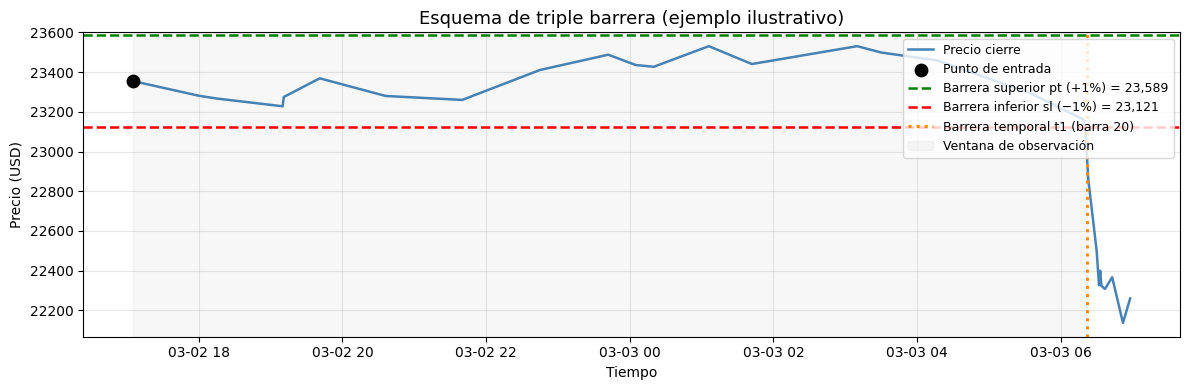

In [128]:
# Gráfica ilustrativa del esquema de triple barrera.
#
# Se selecciona un tramo fijo de 30 barras y, para el primer punto, se dibujan:
#   - Barrera superior (pt): línea horizontal discontinua verde
#   - Barrera inferior (sl): línea horizontal discontinua roja
#   - Barrera temporal (t1): línea vertical discontinua naranja
#   - Punto de entrada    : marcador negro
#
# La gráfica usa THRESHOLD_1 (1%) para ilustrar el esquema fijo.

if 'df_bars' not in globals():
    raise RuntimeError("df_bars no está definido. Ejecute las fases anteriores.")

close = df_bars['close']

# Seleccionar tramo: desde la barra 100 para evitar bordes iniciales
ILUSTRA_START = 100
ILUSTRA_LEN   = 30
ilustra_slice = close.iloc[ILUSTRA_START : ILUSTRA_START + ILUSTRA_LEN]

# Precio de entrada y barreras para el punto ilustrativo
p_entry    = ilustra_slice.iloc[0]
pt_ilustra = p_entry * (1 + THRESHOLD_1)   # barrera superior (+1%)
sl_ilustra = p_entry * (1 - THRESHOLD_1)   # barrera inferior (-1%)

# Índice de la barrera temporal (BARRIER_WINDOW barras desde la entrada)
t1_idx = ilustra_slice.index[min(BARRIER_WINDOW, ILUSTRA_LEN - 1)]

fig, ax = plt.subplots(figsize=(12, 4))

# Serie de precios en el tramo ilustrativo
ax.plot(ilustra_slice.index, ilustra_slice.values,
        color='steelblue', linewidth=1.8, label='Precio cierre')

# Punto de entrada
ax.scatter([ilustra_slice.index[0]], [p_entry],
           color='black', s=80, zorder=5, label='Punto de entrada')

# Barrera superior
ax.axhline(pt_ilustra, color='green', linestyle='--', linewidth=1.8,
           label=f'Barrera superior pt (+{THRESHOLD_1*100:.0f}%) = {pt_ilustra:,.0f}')

# Barrera inferior
ax.axhline(sl_ilustra, color='red', linestyle='--', linewidth=1.8,
           label=f'Barrera inferior sl (−{THRESHOLD_1*100:.0f}%) = {sl_ilustra:,.0f}')

# Barrera temporal
ax.axvline(t1_idx, color='darkorange', linestyle=':', linewidth=2.2,
           label=f'Barrera temporal t1 (barra {BARRIER_WINDOW})')

# Zona de espera entre entrada y barrera temporal
ax.axvspan(ilustra_slice.index[0], t1_idx,
           alpha=0.06, color='gray', label='Ventana de observación')

ax.set_title("Esquema de triple barrera (ejemplo ilustrativo)", fontsize=13)
ax.set_xlabel("Tiempo")
ax.set_ylabel("Precio (USD)")
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4.1. Definición conceptual de las tres barreras

Para cada barra i como evento de entrada, se definen tres barreras:

1. **Barrera superior (take profit)**: precio_entrada × (1 + threshold)
   - Si el precio alcanza este nivel → etiqueta **+1** (movimiento alcista exitoso)

2. **Barrera inferior (stop loss)**: precio_entrada × (1 − threshold)
   - Si el precio alcanza este nivel → etiqueta **−1** (movimiento bajista o pérdida)

3. **Barrera temporal**: ventana de `BARRIER_WINDOW` barras siguientes
   - Si se agotan las barras sin tocar ninguna barrera → etiqueta **0** (sin movimiento significativo)

La etiqueta asignada corresponde a la **primera barrera tocada** en orden cronológico. Esto captura el riesgo real del movimiento, no solo el resultado final.

In [129]:
def get_labels(close, threshold_series, barrier_window):
    """
    Etiqueta cada evento usando el método de triple barrera.

    Para cada barra i como evento de entrada, define:
      - Barrera superior (pt): precio_entrada × (1 + threshold_i)
      - Barrera inferior (sl): precio_entrada × (1 − threshold_i)
      - Barrera temporal    : ventana de barrier_window barras siguientes

    La etiqueta es la primera barrera tocada (en orden cronológico):
      +1 → barrera superior alcanzada
      -1 → barrera inferior alcanzada
       0 → ventana agotada sin tocar ninguna barrera (barrera temporal)

    Los últimos barrier_window eventos NO tienen ventana completa disponible
    y reciben NaN (se eliminarán con dropna() en la celda de aplicación).

    Parámetros
    ----------
    close            : pd.Series de precios de cierre, índice datetime
    threshold_series : pd.Series con el threshold (fracción, e.g. 0.01 = 1%)
                       por cada evento, alineada al mismo índice que close
    barrier_window   : int, número máximo de barras para la barrera temporal

    Retorna
    -------
    pd.Series con etiquetas {-1, 0, +1} y NaN al final, mismo índice que close.
    """
    n      = len(close)
    labels = pd.Series(np.nan, index=close.index, dtype=float)

    # Solo procesamos eventos con ventana futura completa (n - barrier_window)
    for i in range(n - barrier_window):
        precio_entrada = close.iloc[i]
        thresh         = threshold_series.iloc[i]

        # Comprobar que el threshold es válido (no NaN, positivo)
        if pd.isna(thresh) or thresh <= 0:
            continue   # threshold inválido → deja NaN (será eliminado con dropna)

        # Definir barreras
        pt = precio_entrada * (1 + thresh)   # barrera superior
        sl = precio_entrada * (1 - thresh)   # barrera inferior

        # Ventana futura: barras i+1 hasta i+barrier_window (inclusive)
        ventana = close.iloc[i + 1 : i + 1 + barrier_window]

        etiqueta = 0   # por defecto: barrera temporal
        for precio in ventana:
            if precio >= pt:
                etiqueta =  1
                break
            elif precio <= sl:
                etiqueta = -1
                break

        labels.iloc[i] = etiqueta

    # Nota: los últimos barrier_window eventos quedan como NaN porque no
    # disponen de ventana futura completa. Se eliminarán en el dropna().
    return labels

### 4.2. Thresholds 

Se implementan dos esquemas de threshold fijo:

- **Threshold 1%**: `THRESHOLD_1PCT = 0.01`
  - Barreras muy sensibles al movimiento en dollar bars de alta frecuencia
  - Genera más etiquetas ±1 (más eventos etiquetados como éxito/fracaso)
  - Útil para capturar movimientos pequeños pero significativos

- **Threshold 2%**: `THRESHOLD_2PCT = 0.02`
  - Barreras más holgadas, solo etiqueta movimientos sostenidos
  - Produce más etiquetas 0 (más eventos sin movimiento significativo)
  - Útil para filtrar ruido y capturar solo movimientos claros

- **Threshold dinámico basado en volatilidad rolling**

  - El threshold dinámico adapta las barreras al riesgo local del mercado:

  - Se calcula la volatilidad rolling local: `vol_local = log_return.rolling(VOL_WINDOW).std()`
  - El threshold dinámico es: `threshold_dynamic = vol_local × VOL_MULTIPLIER`
  - Las barreras se adaptan automáticamente:
    - **Mercados tranquilos** (baja volatilidad) → barreras más estrechas → más etiquetas ±1
    - **Mercados volátiles** (alta volatilidad) → barreras más amplias → más etiquetas 0



In [130]:
# Aplicación de los tres esquemas de etiquetado sobre df_bars['close'].
#
# Se recalcula log_return localmente (con sufijo _phase5) para evitar
# conflictos con la variable log_return de Fase 3, y se usa para obtener
# la volatilidad rolling que alimenta el threshold dinámico.

if 'df_bars' not in globals():
    raise RuntimeError("df_bars no está definido. Ejecute las fases anteriores.")

close = df_bars['close'].copy()

# log_return local para el threshold dinámico
log_return_p5 = np.log(close).diff()

# Threshold dinámico: volatilidad rolling × multiplicador
threshold_dynamic = log_return_p5.rolling(VOL_WINDOW).std() * VOL_MULTIPLIER

# Threshold fijo como Series (misma longitud y mismo índice que close)
threshold_1pct = pd.Series(THRESHOLD_1, index=close.index)
threshold_2pct = pd.Series(THRESHOLD_2, index=close.index)

print("Aplicando etiquetado de triple barrera...")
print(f"  Total de eventos de entrada  : {len(close)}")
print(f"  Ventana temporal máxima      : {BARRIER_WINDOW} barras")
print(f"  Eventos con ventana completa : {len(close) - BARRIER_WINDOW}")
print()

# ── Esquema 1: threshold fijo 1% ─────────────────────────────────────────────
print("Calculando labels_1pct   (threshold fijo 1%)...", end="  ")
labels_1pct = get_labels(close, threshold_1pct, BARRIER_WINDOW)
print("OK")

# ── Esquema 2: threshold fijo 2% ─────────────────────────────────────────────
print("Calculando labels_2pct   (threshold fijo 2%)...", end="  ")
labels_2pct = get_labels(close, threshold_2pct, BARRIER_WINDOW)
print("OK")

# ── Esquema 3: threshold dinámico ────────────────────────────────────────────
print("Calculando labels_dynamic (threshold dinámico)...", end="  ")
labels_dynamic = get_labels(close, threshold_dynamic, BARRIER_WINDOW)
print("OK")

print()

# ── Construir DataFrame con los 3 esquemas ───────────────────────────────────
df_labels = pd.DataFrame({
    'label_1pct'    : labels_1pct,
    'label_2pct'    : labels_2pct,
    'label_dynamic' : labels_dynamic,
})

# dropna: elimina las primeras VOL_WINDOW filas (sin threshold dinámico calculable)
# y las últimas BARRIER_WINDOW filas (sin ventana futura completa)
n_antes   = len(df_labels)
df_labels = df_labels.dropna()
n_despues = len(df_labels)

print(f"Filas antes de dropna  : {n_antes}")
print(f"Filas eliminadas (NaN) : {n_antes - n_despues}  "
      f"(~{VOL_WINDOW} iniciales sin vol + {BARRIER_WINDOW} finales sin ventana)")
print(f"Filas tras dropna      : {n_despues}")
print(f"  Rango temporal       : {df_labels.index.min()} → {df_labels.index.max()}")
print()

# ── Distribución de etiquetas por esquema ────────────────────────────────────
print("=" * 55)
print("DISTRIBUCIÓN DE ETIQUETAS POR ESQUEMA")
print("=" * 55)
for col in df_labels.columns:
    vc = df_labels[col].astype(int).value_counts().sort_index()
    print(f"\n{col}:")
    for lbl, cnt in vc.items():
        pct = cnt / len(df_labels) * 100
        print(f"  etiqueta {lbl:+d} : {cnt:5d}  ({pct:.1f}%)")

Aplicando etiquetado de triple barrera...
  Total de eventos de entrada  : 128613
  Ventana temporal máxima      : 20 barras
  Eventos con ventana completa : 128593

Calculando labels_1pct   (threshold fijo 1%)...  OK
Calculando labels_2pct   (threshold fijo 2%)...  OK
Calculando labels_dynamic (threshold dinámico)...  OK

Filas antes de dropna  : 128613
Filas eliminadas (NaN) : 40  (~20 iniciales sin vol + 20 finales sin ventana)
Filas tras dropna      : 128573
  Rango temporal       : 2023-02-28 17:33:00 → 2026-02-28 22:24:00

DISTRIBUCIÓN DE ETIQUETAS POR ESQUEMA

label_1pct:
  etiqueta -1 : 27599  (21.5%)
  etiqueta +0 : 73285  (57.0%)
  etiqueta +1 : 27689  (21.5%)

label_2pct:
  etiqueta -1 :  6018  (4.7%)
  etiqueta +0 : 116599  (90.7%)
  etiqueta +1 :  5956  (4.6%)

label_dynamic:
  etiqueta -1 : 63302  (49.2%)
  etiqueta +0 :  1630  (1.3%)
  etiqueta +1 : 63641  (49.5%)


### 4.3. Comparación de distribuciones de etiquetas

Una vez aplicados los tres esquemas de etiquetado, se comparan las distribuciones de etiquetas resultantes:

- **Proporción de cada clase** (+1, 0, −1) para cada esquema
- **Balance de clases**: ¿hay desequilibrio extremo?
- **Visualización**: gráficos de barras comparativos


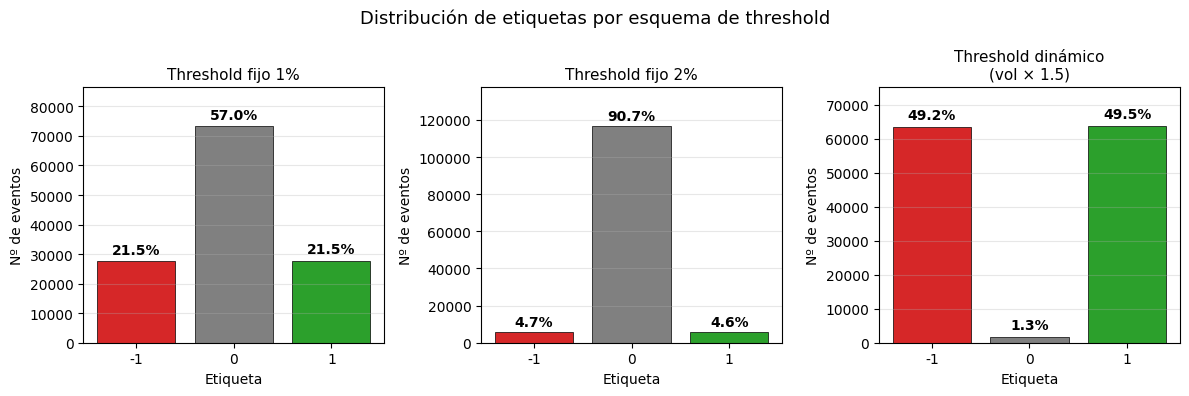

In [131]:
# Gráfica 2: distribución de etiquetas por método (3 subplots, 1×3).
#
# Barras coloreadas: verde (+1), gris (0), rojo (-1).
# El porcentaje de cada clase aparece encima de su barra.

label_colors   = {1: 'tab:green', 0: 'gray', -1: 'tab:red'}
method_titles  = {
    'label_1pct'    : 'Threshold fijo 1%',
    'label_2pct'    : 'Threshold fijo 2%',
    'label_dynamic' : f'Threshold dinámico\n(vol × {VOL_MULTIPLIER})',
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, df_labels.columns):
    vc    = df_labels[col].astype(int).value_counts().sort_index()
    total = vc.sum()
    xs    = [str(int(k)) for k in vc.index]
    ys    = vc.values
    cols  = [label_colors.get(int(k), 'tab:blue') for k in vc.index]

    bars = ax.bar(xs, ys, color=cols, edgecolor='black', linewidth=0.5)

    # Porcentaje encima de cada barra
    for bar, y in zip(bars, ys):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y + total * 0.012,
            f"{y / total * 100:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

    ax.set_title(method_titles[col], fontsize=11)
    ax.set_xlabel("Etiqueta")
    ax.set_ylabel("Nº de eventos")
    ax.set_ylim(0, ys.max() * 1.18)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Distribución de etiquetas por esquema de threshold", fontsize=13)
plt.tight_layout()

plt.show()


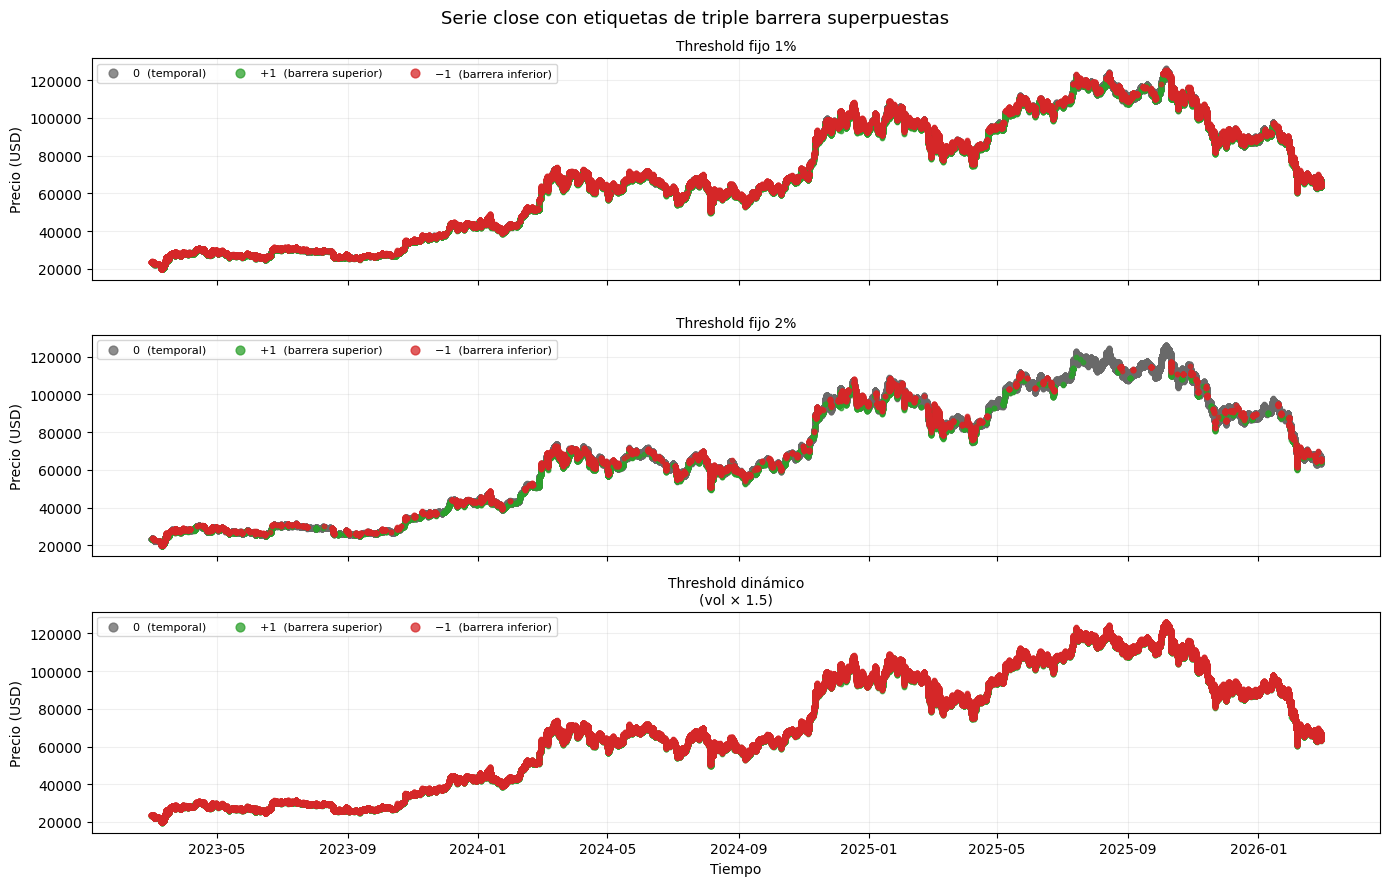

In [132]:
# Gráfica 3: serie close con etiquetas superpuestas (3 subplots apilados, 3×1).
#
# La serie completa de cierre se muestra en gris claro como fondo.
# Sobre ella se superponen puntos coloreados por etiqueta:
#   verde (+1), rojo (-1), gris oscuro (0).
# El tamaño de punto es pequeño (s=10) para no saturar la figura.

close_plot  = df_bars['close']

point_colors = {1: 'tab:green', -1: 'tab:red', 0: 'dimgray'}
point_labels = {1: '+1  (barrera superior)', -1: '−1  (barrera inferior)', 0: '0  (temporal)'}

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, col in zip(axes, df_labels.columns):
    # Fondo: serie completa en gris fino
    ax.plot(close_plot.index, close_plot.values,
            color='lightgray', linewidth=0.8, zorder=1, label='_nolegend_')

    # Puntos etiquetados por clase (orden: 0 primero para que ±1 queden encima)
    for lbl_val in [0, 1, -1]:
        mask    = df_labels[col] == lbl_val
        idx_lbl = df_labels.index[mask]
        ax.scatter(
            idx_lbl,
            close_plot.loc[idx_lbl],
            color=point_colors[lbl_val],
            s=10,
            alpha=0.75,
            zorder=2,
            label=point_labels[lbl_val]
        )

    ax.set_title(method_titles[col], fontsize=10)
    ax.set_ylabel("Precio (USD)")
    ax.legend(fontsize=8, markerscale=2, loc='upper left', ncol=3)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Tiempo")
fig.suptitle("Serie close con etiquetas de triple barrera superpuestas", fontsize=13)
plt.tight_layout()

plt.show()


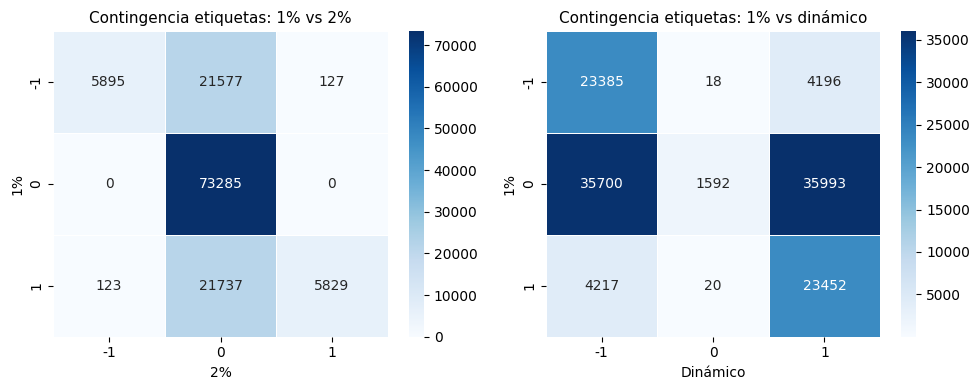

In [133]:
# Gráfica 4: tablas de contingencia entre esquemas de etiquetado.
#
# Se generan dos heatmaps (guardados en un único archivo 15_label_contingency.png):
#   - Izquierda: 1% vs 2%         → cuántos eventos fijo-1% quedan como 0 con 2%
#   - Derecha  : 1% vs dinámico   → grado de acuerdo entre umbral fijo y adaptativo
#
# Paleta "Blues", anotaciones de recuento absoluto.

lbl_1   = df_labels['label_1pct'].astype(int)
lbl_2   = df_labels['label_2pct'].astype(int)
lbl_dyn = df_labels['label_dynamic'].astype(int)

ct_1v2 = pd.crosstab(lbl_1, lbl_2,
                      rownames=['1%'], colnames=['2%'])
ct_1vd = pd.crosstab(lbl_1, lbl_dyn,
                      rownames=['1%'], colnames=['Dinámico'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(ct_1v2, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Contingencia etiquetas: 1% vs 2%", fontsize=11)

sns.heatmap(ct_1vd, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Contingencia etiquetas: 1% vs dinámico", fontsize=11)

plt.tight_layout()

plt.show()


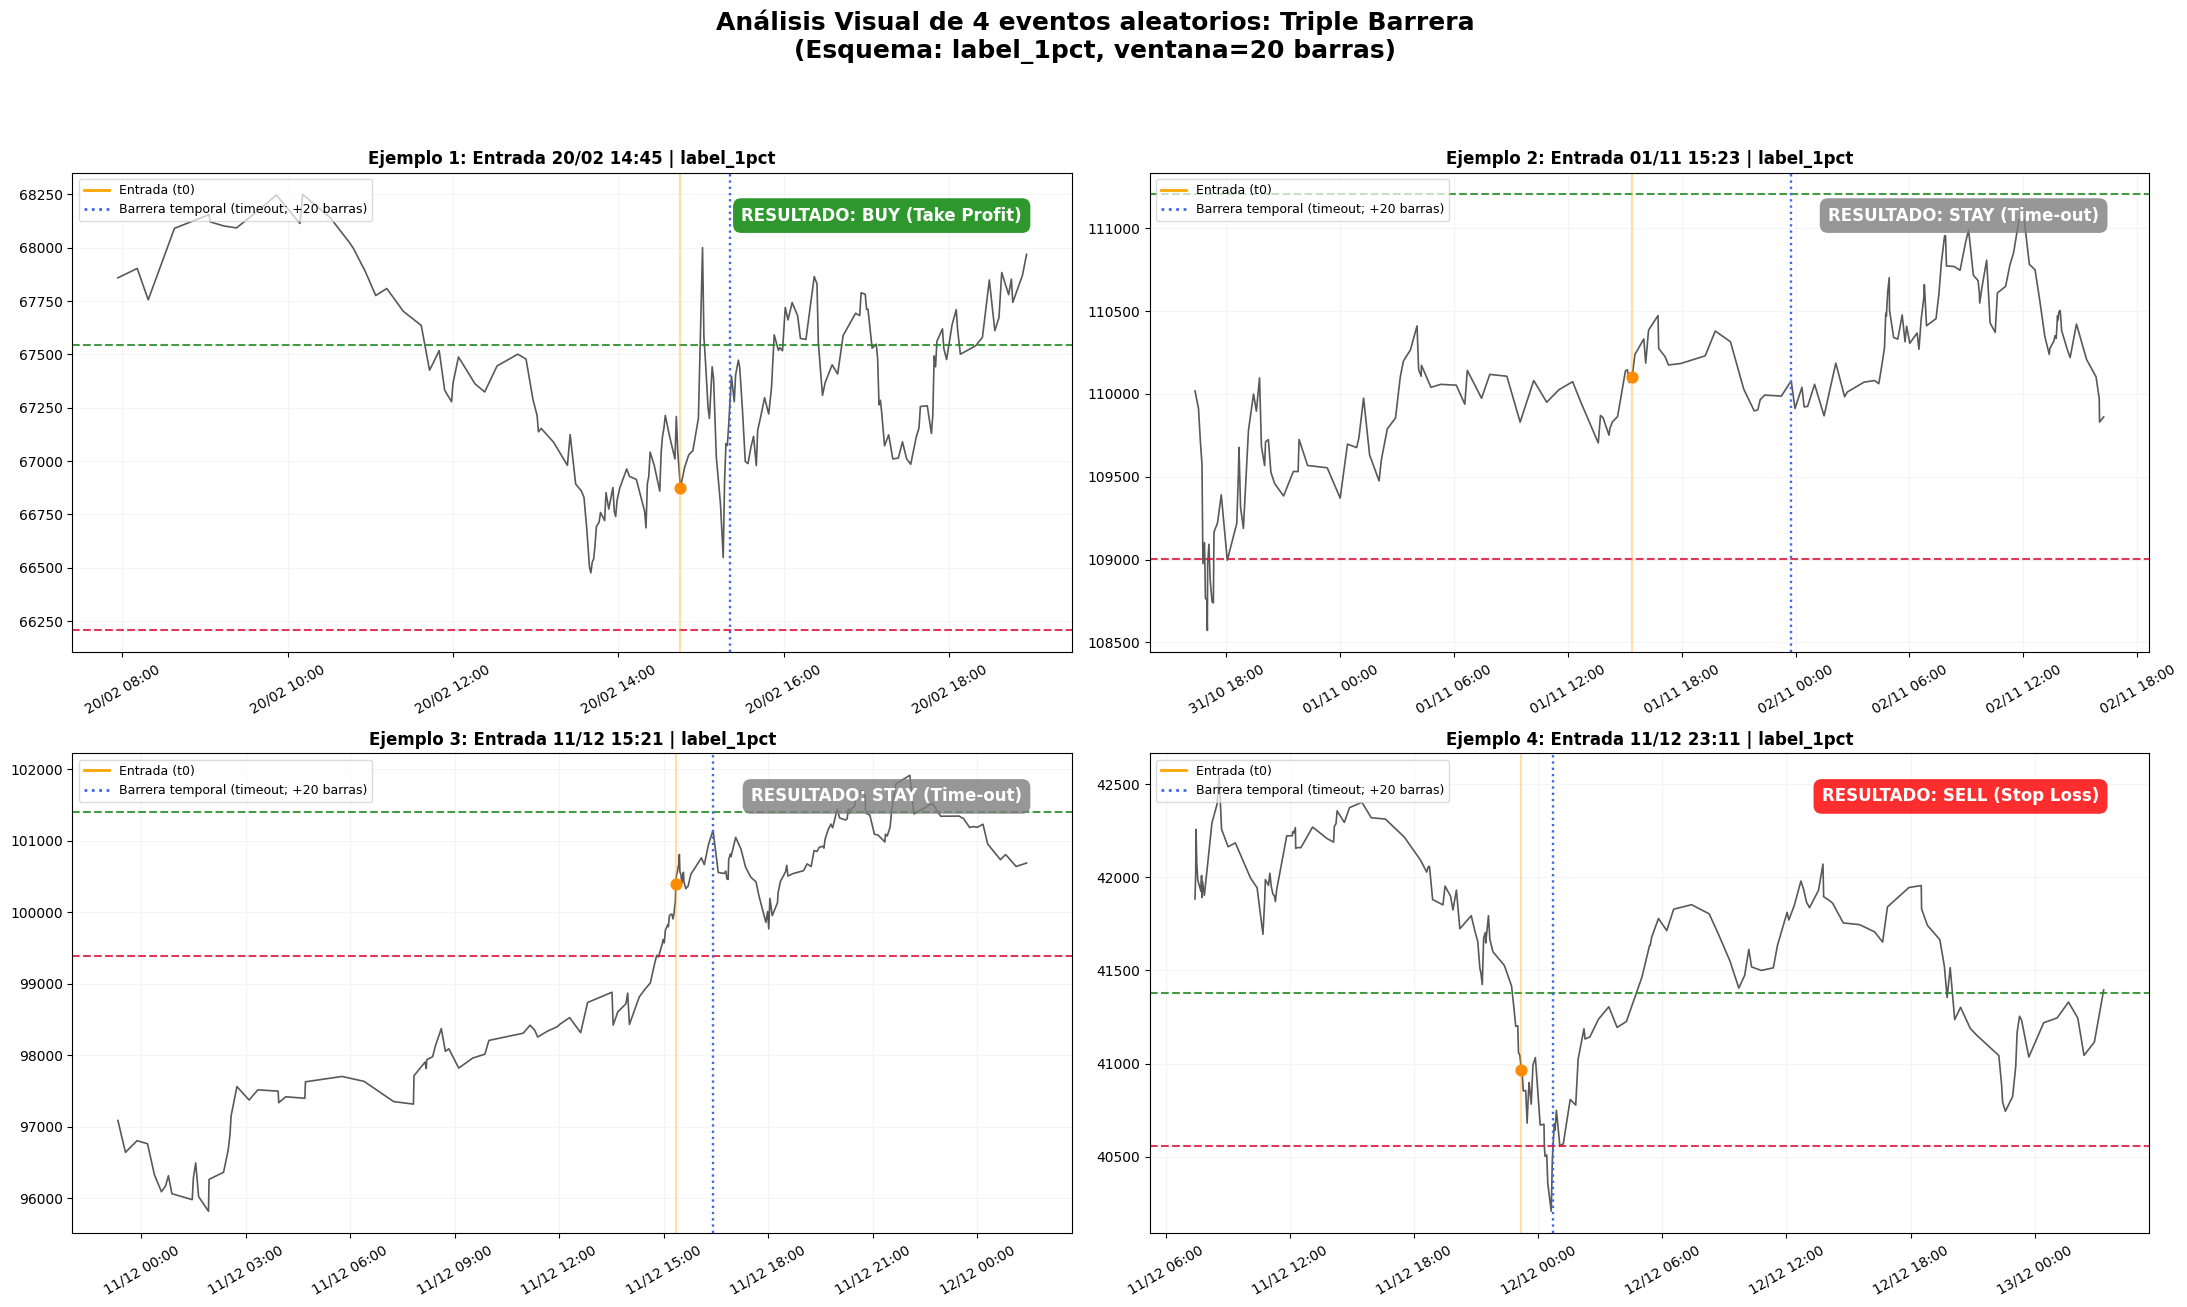

In [135]:
# Visualización (Fase 4): 4 eventos aleatorios del etiquetado por triple barrera
#

if 'df_labels' not in globals():
    raise RuntimeError("df_labels no está definido. Ejecuta primero la Fase 4 (cálculo de labels).")
if 'close' not in globals():
    raise RuntimeError("`close` no está definido. Ejecuta primero la Fase 4 (se define desde df_bars['close']).")

# ── Qué esquema visualizar ────────────────────────────────────────────────────
SCHEME_TO_PLOT = 'label_1pct'   # 'label_1pct' | 'label_2pct' | 'label_dynamic'

threshold_by_scheme = {
    'label_1pct'   : threshold_1pct,
    'label_2pct'   : threshold_2pct,
    'label_dynamic': threshold_dynamic,
}

if SCHEME_TO_PLOT not in df_labels.columns:
    raise ValueError(f"SCHEME_TO_PLOT='{SCHEME_TO_PLOT}' no existe en df_labels: {list(df_labels.columns)}")
if SCHEME_TO_PLOT not in threshold_by_scheme:
    raise ValueError(f"No hay threshold asociado para {SCHEME_TO_PLOT}.")

labels_scheme    = df_labels[SCHEME_TO_PLOT].astype(int)
threshold_scheme = threshold_by_scheme[SCHEME_TO_PLOT]

# ── Selección reproducible de 4 eventos aleatorios ────────────────────────────
random.seed(1234)
selected_events = random.sample(list(labels_scheme.index), 4)

# ── Figura 2×2 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()

# Buffer visual en nº de barras (no en horas, para que funcione con cualquier frecuencia)
BUFFER_BARS = 80

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='orange', lw=2, ls='-', label='Entrada (t0)'),
    Line2D([0], [0], color='royalblue', lw=2, ls=':', label=f'Barrera temporal (timeout; +{BARRIER_WINDOW} barras)'),
]

for i, t0 in enumerate(selected_events):
    # Posición entera en la serie (para poder cortar por barras)
    i0 = int(close.index.get_loc(t0))

    entry_price = float(close.loc[t0])
    thr         = float(threshold_scheme.loc[t0])

    # Barreras (nivel de precio)
    tp_level = entry_price * (1 + thr)
    sl_level = entry_price * (1 - thr)

    # Ventana futura (BARRIER_WINDOW barras) y detección del primer toque
    future = close.iloc[i0 + 1 : i0 + 1 + BARRIER_WINDOW]
    t_timeout = close.index[i0 + BARRIER_WINDOW]

    result_label = 0
    t_first      = t_timeout

    for t, p in future.items():
        p = float(p)
        if p >= tp_level:
            result_label = 1
            t_first = t
            break
        if p <= sl_level:
            result_label = -1
            t_first = t
            break

    # Texto/color de resultado
    if result_label == 1:
        result_text  = 'BUY (Take Profit)'
        result_color = 'green'
    elif result_label == -1:
        result_text  = 'SELL (Stop Loss)'
        result_color = 'red'
    else:
        result_text  = 'STAY (Time-out)'
        result_color = 'gray'

    # Slice para dibujar (buffer antes/después)
    left  = max(0, i0 - BUFFER_BARS)
    right = min(len(close) - 1, i0 + BARRIER_WINDOW + BUFFER_BARS)
    price_slice = close.iloc[left : right + 1]

    ax = axes[i]

    # Precio
    ax.plot(price_slice.index, price_slice.values,
            label='close', color='black', alpha=0.65, lw=1.2)

    # Barreras y tiempos
    ax.axhline(y=tp_level, color='forestgreen', ls='--', lw=1.5, alpha=0.85)
    ax.axhline(y=sl_level, color='crimson',     ls='--', lw=1.5, alpha=0.85)

    ax.axvline(x=t0,        color='orange',    ls='-', alpha=0.35)
    ax.axvline(x=t_timeout, color='royalblue', ls=':', lw=1.7)

    ax.scatter(t0, entry_price, color='darkorange', s=60, zorder=5)

    # Caja de resultado
    ax.text(
        0.95, 0.90,
        f"RESULTADO: {result_text}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        color='white',
        ha='right',
        bbox=dict(facecolor=result_color, alpha=0.82, edgecolor='none', boxstyle='round,pad=0.5')
    )

    # Formato
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(
        f"Ejemplo {i+1}: Entrada {t0.strftime('%d/%m %H:%M')} | {SCHEME_TO_PLOT}",
        fontweight='bold'
    )
    ax.grid(alpha=0.12)

    ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.7)

plt.subplots_adjust(wspace=0.25, hspace=0.35)
plt.suptitle(
    "Análisis Visual de 4 eventos aleatorios: Triple Barrera\n"
    f"(Esquema: {SCHEME_TO_PLOT}, ventana={BARRIER_WINDOW} barras)",
    fontsize=18,
    fontweight='bold',
    y=0.96
)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

### 4.4 Cierre de la fase: decisión del esquema principal

**Lectura de las gráficas:**

- **Ilustración triple barrera**: muestra visualmente por qué el método es superior al retorno fijo: el precio puede rebotar desde el stop loss y recuperarse antes de la barrera temporal, pero la etiqueta ya capturó ese movimiento adverso. La zona sombreada delimita la ventana de observación; cualquier cruce de las líneas discontinuas dentro de esa zona determina la etiqueta.

- **Distribución de etiquetas**: el threshold fijo 1% produce el mejor equilibrio entre ±1 y 0 en dollar bars de alta frecuencia, porque los movimientos del 1% son frecuentes. El 2% genera más etiquetas 0 (la mayoría de movimientos no llegan a ±2% en BARRIER_WINDOW barras). El threshold dinámico produce una distribución intermedia que varía con el régimen de volatilidad.

- **Serie con etiquetas**: permite detectar si los ±1 se concentran en zonas de alta actividad (movimientos sostenidos) y los 0 en periodos laterales. Una distribución cromática visualmente uniforme indica un etiquetado estable. Clusters de un solo color pueden señalar regímenes de volatilidad diferentes o zonas de tendencia fuerte.

- **Contingencia**: la tabla 1% vs 2% muestra cuántos eventos clasificados como ±1 al 1% quedan como 0 al 2%: esto cuantifica directamente qué fracción de los movimientos capturados al 1% no llegan al umbral del 2%. La tabla 1% vs dinámico mide el acuerdo entre umbral fijo y adaptativo: si la volatilidad local es próxima a THRESHOLD_1, el acuerdo es alto; si la volatilidad es baja, el threshold dinámico es más estrecho que el 1% y genera más ±1.

**Discusión sobre desequilibrio de clases:**

Con thresholds fijos, el método de triple barrera suele producir asimetría de clases cuando el mercado tiene una tendencia dominante (más +1 que −1 en tendencias alcistas, o viceversa). Un exceso de etiquetas 0 puede crear clasificadores que predicen siempre la clase mayoritaria con alta exactitud pero sin valor predictivo real. En fases posteriores será necesario evaluar con métricas robustas al desbalance (F1 por clase, precisión/recall, AUC multiclase) y considerar técnicas de reequilibrio si la diferencia es extrema.

**Decisión de esquema principal:**

Se elige `labels_1pct` como referencia principal porque:
- Es el threshold más sensible al movimiento en dollar bars de alta frecuencia (BTC)
- Produce el mejor equilibrio entre clases ±1 y 0 respecto a los otros dos esquemas
- Es completamente reproducible y no depende de la estimación de la volatilidad rolling
- `df_labels` mantiene los tres esquemas para análisis comparativos posteriores

In [136]:
# Variable final de la Fase 5: etiquetas del esquema fijo 1%.
# Será el input directo para la Fase 6 (validación cruzada temporal).
labels_main = labels_1pct.copy()

print("=" * 60)
print("OUTPUT FINAL DE LA FASE 5")
print("=" * 60)

print(f"\ndf_labels (3 esquemas):")
print(f"  shape          : {df_labels.shape}")
print(f"  columnas       : {list(df_labels.columns)}")
print(f"  rango temporal : {df_labels.index.min()} → {df_labels.index.max()}")
print(f"  NaNs totales   : {int(df_labels.isna().sum().sum())}")

print(f"\nlabels_main (esquema fijo 1%):")
lm_valid = labels_main.dropna().astype(int)
vc_main  = lm_valid.value_counts().sort_index()
print(f"  total eventos  : {len(lm_valid)}")
for lbl, cnt in vc_main.items():
    pct = cnt / len(lm_valid) * 100
    print(f"  etiqueta {lbl:+d}   : {cnt:5d}  ({pct:.1f}%)")

print()
print("Fase 5 completada.")
print("labels_main y df_labels listos para la Fase 6 (validación cruzada temporal).")

OUTPUT FINAL DE LA FASE 5

df_labels (3 esquemas):
  shape          : (128573, 3)
  columnas       : ['label_1pct', 'label_2pct', 'label_dynamic']
  rango temporal : 2023-02-28 17:33:00 → 2026-02-28 22:24:00
  NaNs totales   : 0

labels_main (esquema fijo 1%):
  total eventos  : 128593
  etiqueta -1   : 27604  (21.5%)
  etiqueta +0   : 73295  (57.0%)
  etiqueta +1   : 27694  (21.5%)

Fase 5 completada.
labels_main y df_labels listos para la Fase 6 (validación cruzada temporal).


## 5. Validación cruzada temporal y definición de splits

La validación cruzada consiste en particionar los datos en k partes. Cada una de esas partes es el conjunto test mientras que el resto de datos son los datos de entrenamiento. Cada uno de los pares de datos de entrenamiento y test son independientes con respecto al resto de pares, por lo que no hay filas duplicadas.

Gracias a la validación cruzada, se obtienen k modelos que se agregan entre sí para obtener el resultado medio de los modelos entrenados.

Sin embargo, en series temporales y particularmente en series financieras, no es posible aplicar estas particiones de datos porque existe autocorrelación entre las observaciones. Es decir, la observación $x_t$ depende significativamente de las observaciones anteriores.

Para solucionar esto, hay que dejar una serie de observaciones antes (**purga**) y después (**embargo**) del conjunto test que no se incluyan en el conjunto de entrenamiento para hacer frente a la problemática de la autocorrelación.


#### 5.1 Funciones

Gracias a los bloques de datos de purga y embargo, que no se utilizan para el entrenamiento ni evaluación del modelo, solventamos el problema de autocorrelación.

En el gráfico superior se observa como cambiaría la asignación de los diferentes conjuntos de datos en función del parámetro k. Este parámetro determina particiones habrá que hacer sobre los datos. En este caso se han seleccionado los parámetros 3,5 y 10.

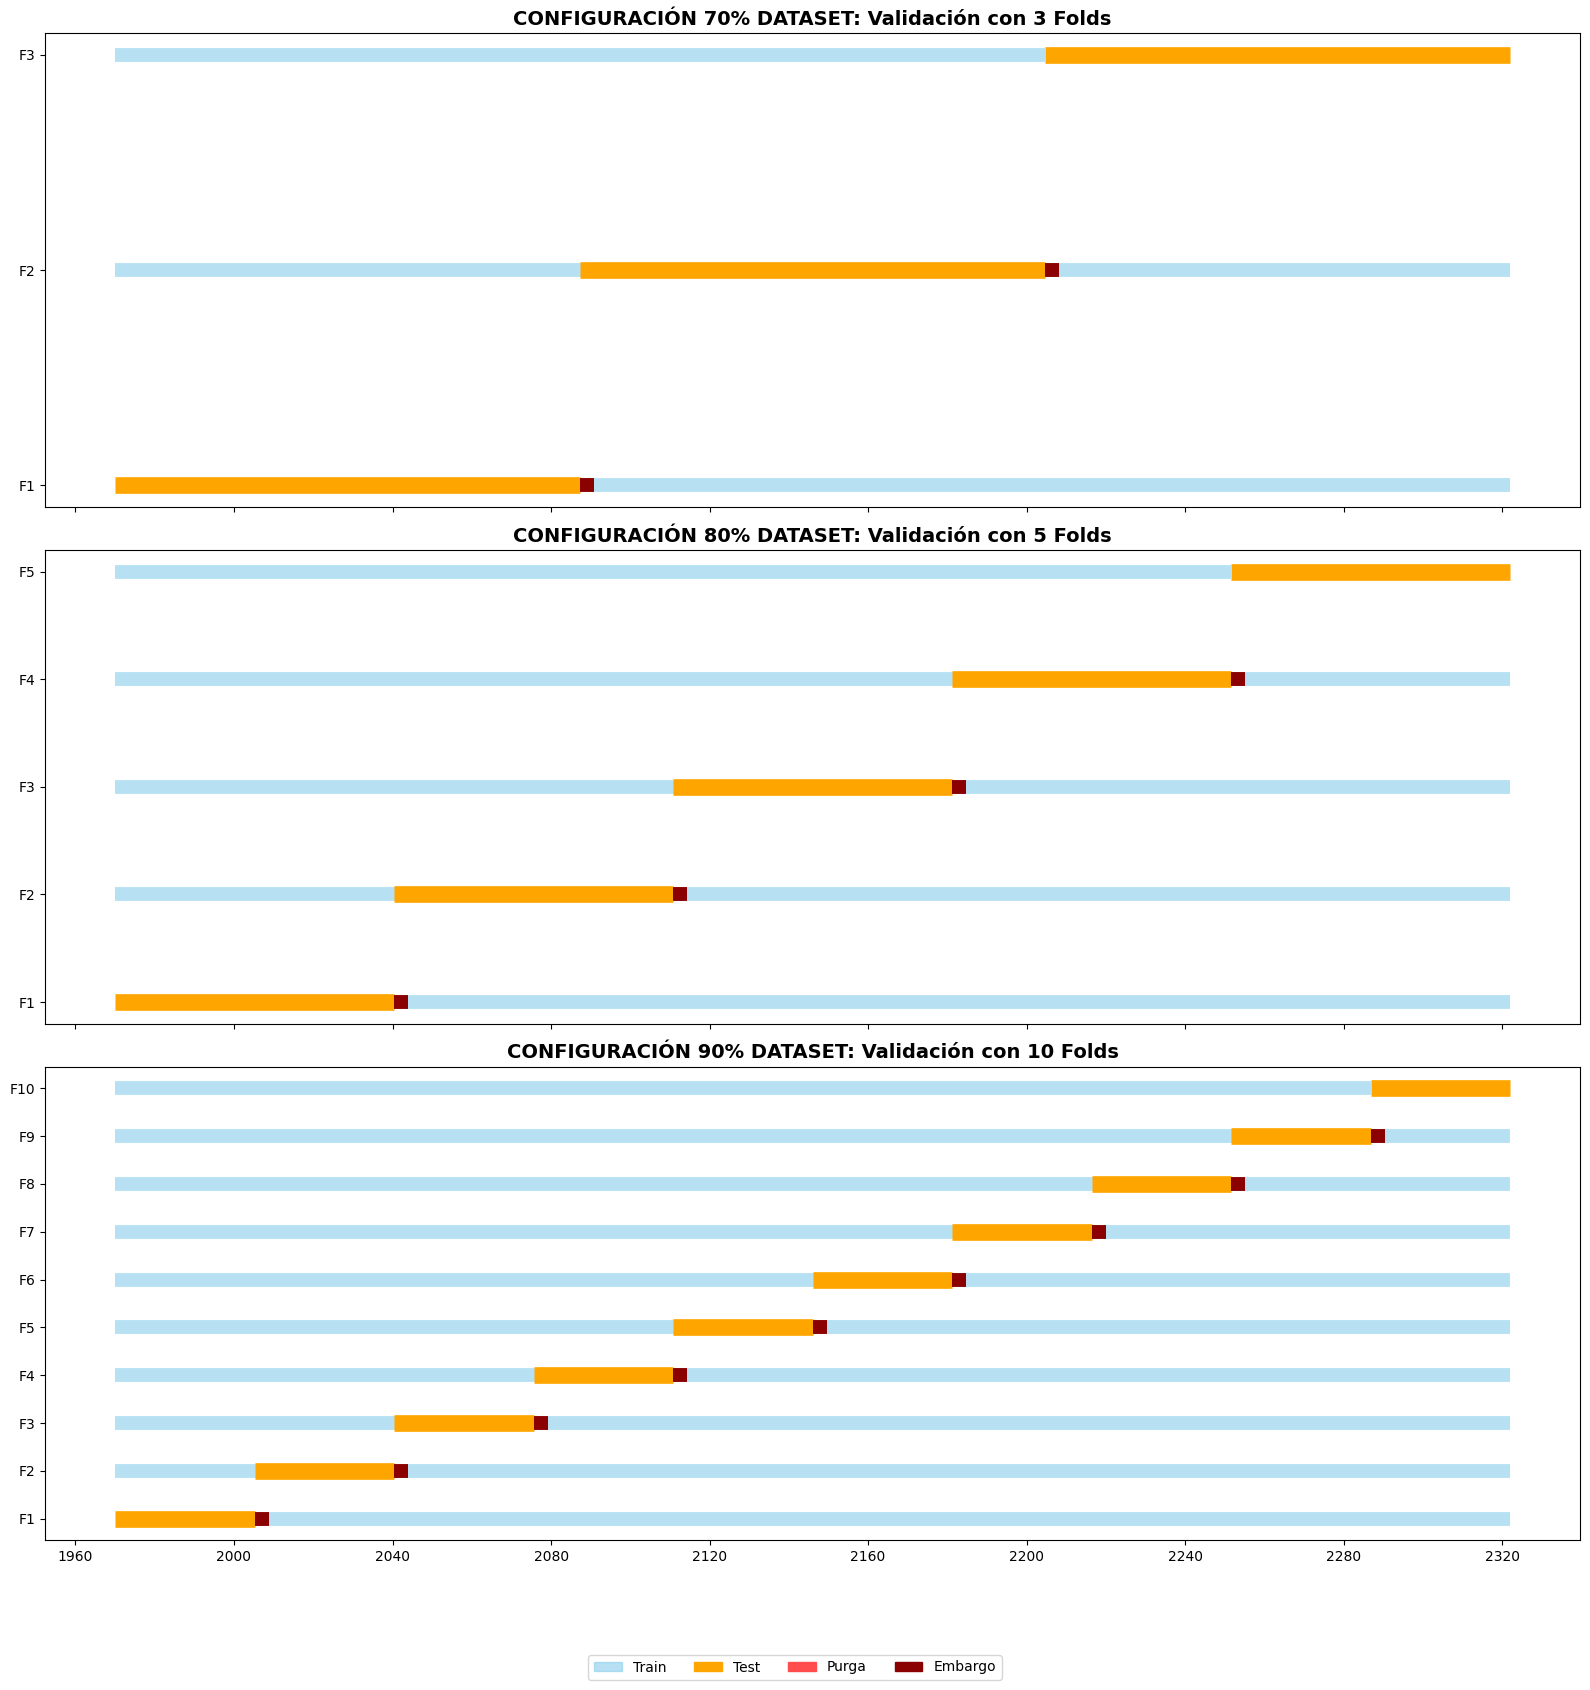

In [137]:
def get_cv_labels_visual(t1, test_idx, pct_embargo=0.01, visual_extra_purge=0.02):
    """
    Función auxiliar para calcular los índices de Train, Test, Purga y Embargo.
    """
    # Índices numéricos del test
    test = set(test_idx)
    
    # Determinamos los límites temporales del test para purgar
    test_times = t1.iloc[test_idx]
    test_start = test_times.index.min()
    test_end = test_times.max() # Basado en t1 (final de la barrera vertical)
    
    # 1. PURGA (Datos que terminan después de que empiece el test)
    # Buscamos eventos que empezaron antes del test pero terminan dentro del test
    purge = set(t1[(t1 > test_start) & (t1.index < test_start)].index)
    
    # 2. EMBARGO (Datos que empiezan justo después del test)
    embargo_period = int(len(t1) * pct_embargo)
    last_test_idx = test_idx[-1]
    embargo_idx = np.arange(last_test_idx + 1, min(last_test_idx + 1 + embargo_period, len(t1)))
    embargo = set(embargo_idx)
    
    # 3. TRAIN (Todo lo que no es test, ni purga, ni embargo)
    all_indices = set(np.arange(len(t1)))
    train = all_indices - test - purge - embargo
    
    # Convertimos a listas para matplotlib
    return list(train), list(test), list(purge), list(embargo)

def plot_enhanced_cv_proportional(t1, proportions=[0.7, 0.8, 0.9]):
    # Definimos un número de Folds distinto para cada proporción
    folds_por_proporcion = {0.7: 3, 0.8: 5, 0.9: 10}
    
    fig, axes = plt.subplots(len(proportions), 1, figsize=(16, 6 * len(proportions)), sharex=True)
    c_train, c_test, c_purge, c_embargo = 'skyblue', 'orange', '#ff4d4d', '#8b0000'

    for idx, pct in enumerate(proportions):
        ax = axes[idx]
        n_splits = folds_por_proporcion[pct] # Aquí está el cambio clave
        indices = np.arange(len(t1))
        kf = KFold(n_splits=n_splits)
        
        for i, (_, test_idx) in enumerate(kf.split(indices)):
            train, test, purge, embargo = get_cv_labels_visual(t1, test_idx, pct_embargo=0.01, visual_extra_purge=0.02)
            
            if train: ax.hlines(i, min(train), max(train), colors=c_train, lw=10, alpha=0.6)
            if purge: ax.hlines(i, min(purge), max(purge), colors=c_purge, lw=10)
            if test: ax.hlines(i, min(test), max(test), colors=c_test, lw=12)
            if embargo: ax.hlines(i, min(embargo), max(embargo), colors=c_embargo, lw=10)

        ax.set_title(f"CONFIGURACIÓN {int(pct*100)}% DATASET: Validación con {n_splits} Folds", 
                     fontsize=14, fontweight='bold')
        ax.set_yticks(range(n_splits))
        ax.set_yticklabels([f'F{i+1}' for i in range(n_splits)])

    # Leyenda manual (igual que antes)
    legend_elements = [
        mpatches.Patch(color=c_train, alpha=0.6, label='Train'),
        mpatches.Patch(color=c_test, label='Test'),
        mpatches.Patch(color=c_purge, label='Purga'),
        mpatches.Patch(color=c_embargo, label='Embargo')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.show()

# En este pipeline (Fase 4/5) no existe `events['t1']` como en AFML.
# Para la visualización, aproximamos `t1` como el timeout vertical de la triple barrera:
#   t1 = t0 + BARRIER_WINDOW (en nº de barras).

import pandas as pd

if 'df_labels' not in globals():
    raise RuntimeError("df_labels no está definido; ejecuta antes la Fase 4/5.")
if 'close' not in globals():
    raise RuntimeError("`close` no está definido; ejecuta primero la Fase 4/5 (df_bars['close']).")

# Índices de los eventos válidos (ya sin NaNs por dropna)
_event_starts = df_labels.index

# Posiciones de t0 dentro del índice completo de close
_pos = close.index.get_indexer(_event_starts)
if (_pos < 0).any():
    missing = int((_pos < 0).sum())
    raise RuntimeError(f"No se pudieron mapear {_event_starts.shape[0]} starts a close.index (faltan {missing}).")

# Timeout vertical: t0 + BARRIER_WINDOW barras
_end_pos = _pos + BARRIER_WINDOW
if (_end_pos >= len(close.index)).any():
    raise RuntimeError("Se intentó acceder a t1 fuera del rango temporal de close (bordes de ventana).")
_end_times = close.index[_end_pos]

# Series t1 con el mismo índice que los eventos
_t1_series = pd.Series(_end_times, index=_event_starts)

plot_enhanced_cv_proportional(_t1_series)

#### 5.2 Visualizacion

Por último, se aprecia la selección de los conjuntos de datos para una validación cruzada (k=5) sobre los precios de BTC. Aparecen remarcados los conjuntos de datos test, purga y embargo. Estos dos últimos no se utilizarían en el modelo.

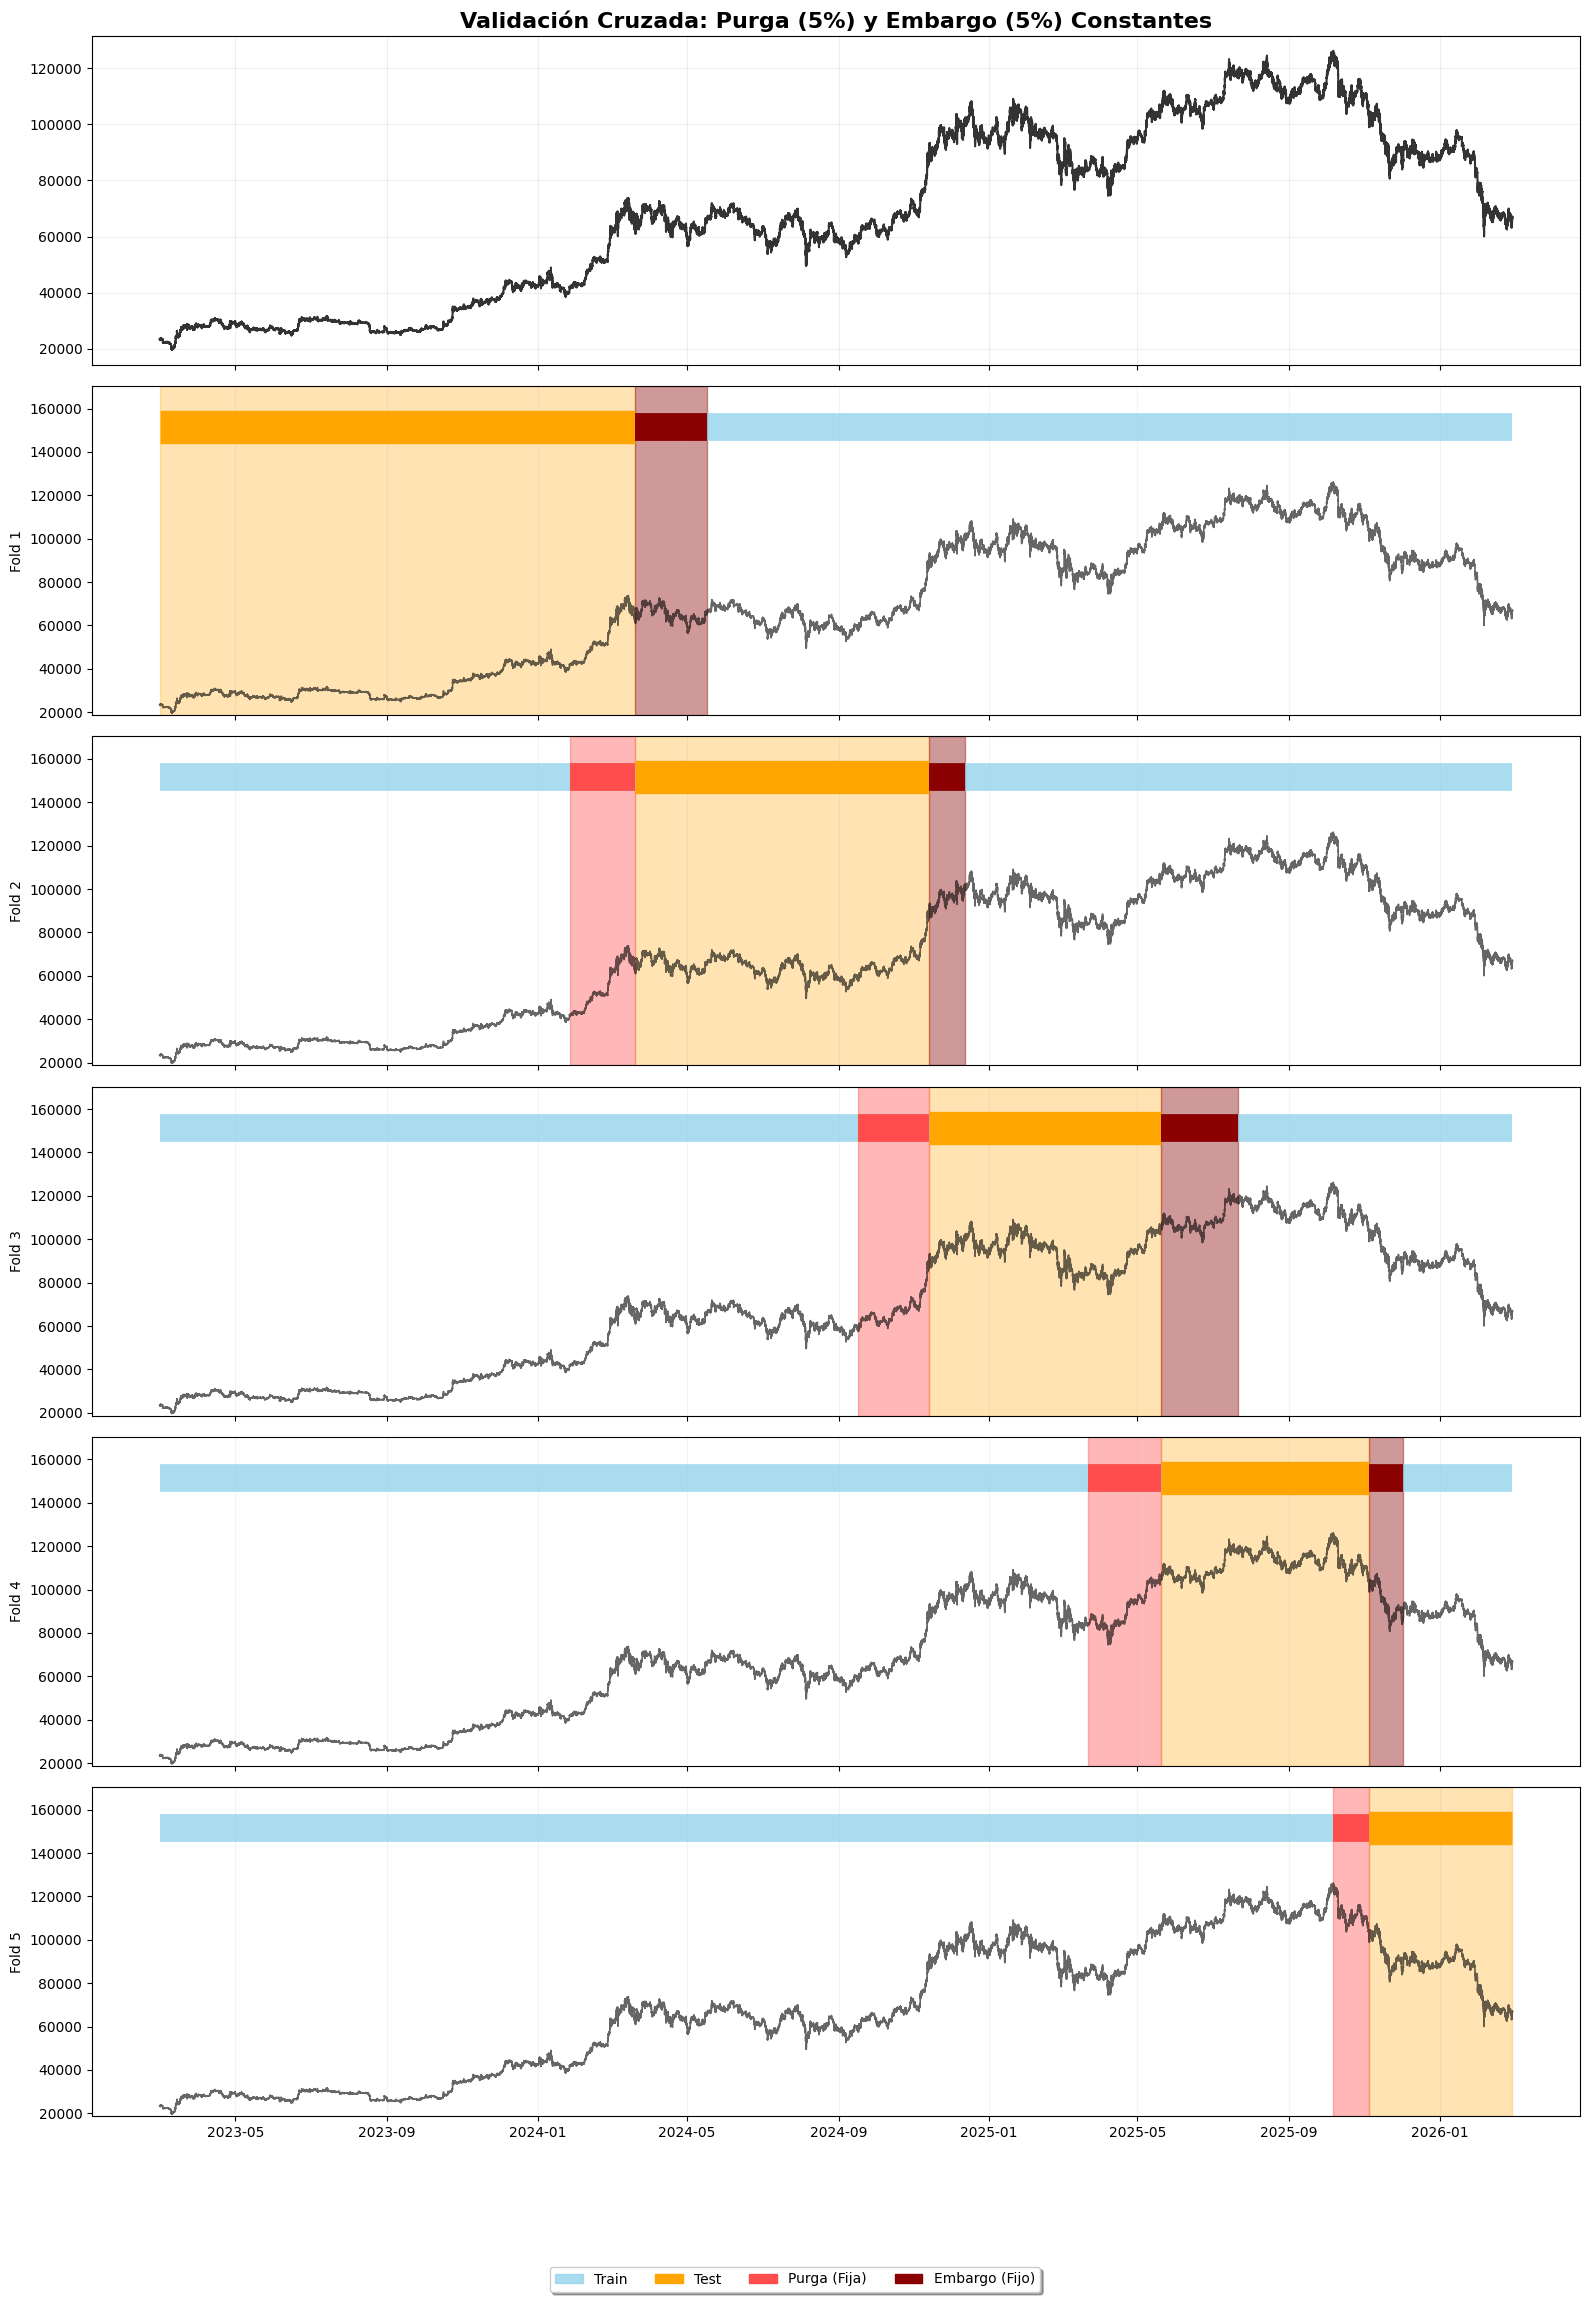

In [138]:
def get_cv_labels_fixed_proportions(t1, test_idx, pct_purge=0.05, pct_embargo=0.05):
    """
    Calcula Train, Test, Purge y Embargo asegurando que Purga y Embargo 
    tengan siempre el mismo tamaño relativo al dataset total.
    """
    all_indices = np.arange(len(t1))
    
    # 1. Definir Test
    test_idx_list = list(test_idx)
    
    # 2. Definir Purga (Tamaño fijo ANTES del Test)
    # Calculamos cuántas muestras representan el pct_purge
    purge_size = int(len(t1) * pct_purge)
    first_test_idx = test_idx[0]
    
    # La purga son los N índices previos al inicio del test
    purge_idx = np.arange(max(0, first_test_idx - purge_size), first_test_idx)
    
    # 3. Definir Embargo (Tamaño fijo DESPUÉS del Test)
    embargo_size = int(len(t1) * pct_embargo)
    last_test_idx = test_idx[-1]
    
    # El embargo son los N índices posteriores al fin del test
    embargo_idx = np.arange(last_test_idx + 1, min(last_test_idx + 1 + embargo_size, len(t1)))
    
    # 4. Definir Train (Lo que sobra)
    test_set = set(test_idx)
    purge_set = set(purge_idx)
    embargo_set = set(embargo_idx)
    
    train_idx = sorted(list(set(all_indices) - test_set - purge_set - embargo_set))
    
    # Convertir a Timestamps para el gráfico de precios
    return {
        'train': list(t1.index[train_idx]),
        'test': list(t1.index[test_idx_list]),
        'purge': list(t1.index[purge_idx]),
        'embargo': list(t1.index[embargo_idx])
    }

# ========================================================
# 2. FUNCIÓN DE GRAFICADO UNIFICADA
# ========================================================
def plot_cv_final_fixed_ratios(price_serie, t1, n_splits=5, p_size=0.05, e_size=0.05):
    kf = KFold(n_splits=n_splits)
    fig, axes = plt.subplots(n_splits + 1, 1, figsize=(16, 4 * (n_splits + 1)), sharex=True)
    
    # Colores consistentes con tus entregas anteriores
    c_train, c_test, c_purge, c_embargo = 'skyblue', 'orange', '#ff4d4d', '#8b0000'
    c_base = 'black'

    # Subplot superior: Serie Completa
    axes[0].plot(price_serie.index, price_serie.values, color=c_base, lw=1.5, alpha=0.8)
    axes[0].set_title(f"Validación Cruzada: Purga ({int(p_size*100)}%) y Embargo ({int(e_size*100)}%) Constantes", 
                      fontsize=16, fontweight='bold')
    axes[0].grid(alpha=0.2)

    for i, (_, test_idx_raw) in enumerate(kf.split(price_serie.index)):
        ax = axes[i + 1]
        
        # Obtenemos etiquetas con proporciones fijas
        res = get_cv_labels_fixed_proportions(t1, test_idx_raw, pct_purge=p_size, pct_embargo=e_size)
        
        # Dibujamos el precio de fondo
        ax.plot(price_serie.index, price_serie.values, color=c_base, lw=1.2, alpha=0.6)

        # Sombreados de fondo (ahora siempre medirán lo mismo visualmente)
        if res['test']: ax.axvspan(min(res['test']), max(res['test']), color=c_test, alpha=0.3)
        if res['purge']: ax.axvspan(min(res['purge']), max(res['purge']), color=c_purge, alpha=0.4)
        if res['embargo']: ax.axvspan(min(res['embargo']), max(res['embargo']), color=c_embargo, alpha=0.4)

        # Barras de estructura
        y_pos = price_serie.max() * 1.20
        lw_bar = 20
        if res['train']: ax.hlines(y_pos, min(res['train']), max(res['train']), colors=c_train, lw=lw_bar, alpha=0.7)
        if res['purge']: ax.hlines(y_pos, min(res['purge']), max(res['purge']), colors=c_purge, lw=lw_bar)
        if res['test']: ax.hlines(y_pos, min(res['test']), max(res['test']), colors=c_test, lw=lw_bar + 4)
        if res['embargo']: ax.hlines(y_pos, min(res['embargo']), max(res['embargo']), colors=c_embargo, lw=lw_bar)

        ax.set_ylim(price_serie.min() * 0.95, price_serie.max() * 1.35)
        ax.set_ylabel(f"Fold {i+1}")
        ax.grid(axis='x', alpha=0.15)

    # Leyenda y estética final
    legend_elements = [
        mpatches.Patch(color=c_train, alpha=0.7, label='Train'),
        mpatches.Patch(color=c_test, label='Test'),
        mpatches.Patch(color=c_purge, label='Purga (Fija)'),
        mpatches.Patch(color=c_embargo, label='Embargo (Fijo)')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.02), shadow=True)
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()

# Ejecución (Ejemplo con 5% de Purga y 5% de Embargo)
# En este pipeline no existe `events['t1']` (Fase 4 etiqueta con ventanas futuras).
# Para esta visualización, aproximamos `t1` como timeout vertical:
#   t1 = t0 + BARRIER_WINDOW barras, donde t0 son los starts válidos (df_labels.index).

import pandas as pd

if 'df_labels' not in globals():
    raise RuntimeError("df_labels no está definido; ejecuta antes la Fase 4/5.")

# En el pipeline actual la serie se llama `close` (Fase 4: close = df_bars['close']).
# `close_btc` puede no existir (venía de versiones anteriores del notebook).
if 'close_btc' in globals():
    _close_series = close_btc
elif 'close' in globals():
    _close_series = close
else:
    raise RuntimeError("No existe ni `close_btc` ni `close`. Ejecuta la Fase 4/5 donde se define close.")

_event_starts = df_labels.index

_pos = _close_series.index.get_indexer(_event_starts)
if (_pos < 0).any():
    missing = int((_pos < 0).sum())
    raise RuntimeError(f"No se pudieron mapear {_event_starts.shape[0]} starts al índice de la serie de precios (faltan {missing}).")

_end_pos = _pos + BARRIER_WINDOW
if (_end_pos >= len(_close_series.index)).any():
    raise RuntimeError("Se intentó acceder a t1 fuera del rango temporal de la serie de precios (bordes de ventana).")
_end_times = _close_series.index[_end_pos]

_t1_series = pd.Series(_end_times, index=_event_starts)

plot_cv_final_fixed_ratios(
    _close_series.loc[_event_starts],
    _t1_series,
    n_splits=5,
    p_size=0.05,
    e_size=0.05,
)